## Модели условной гетероскедастичности: волатильность недельного индекса Доу-Джонса

Ряд из папки `Series` - недельные значения индекса Доу-Джонса на закрытии торгов,
162 точки с июля 1971 по август 1974 года. Из шести предложенных рядов этот единственный
финансовый, а модели ARCH и GARCH придуманы именно под финансовые данные: они описывают
не сам уровень ряда, а то, как меняется его разброс.

Отрезок выбран удачно для такой задачи: он начинается в спокойном рынке 1971-1972 годов
и заканчивается в разгар падения 1973-1974, то есть внутри одного короткого ряда лежат
и тихий период, и бурный.

Порядок работы такой. Сначала ряд приводится к стационарному виду - без этого GARCH считать
нельзя. Дальше проверяется, есть ли в нем вообще то, ради чего эти модели строят: меняющаяся
во времени дисперсия. Потом перебором по информационному критерию подбираются параметры ARIMA
для среднего, и уже на остатках этой модели строится GARCH. Качество меряется на отложенных
последних 26 неделях, которые в подборе не участвуют, и сравнивается с простыми правилами,
которые модель обязана обойти

### Задача 1. Ряд и разделение на обучение и проверку

Прежде чем строить модель, надо посмотреть на сам ряд: цел ли календарь, как ведет себя
уровень, где проходит граница между спокойным и бурным периодами.

Разделение делается **по времени**, а не случайно: у временного ряда перемешивание точек
само по себе утечка. На проверку уходят последние 26 недель - ровно полгода. Все дальнейшие
оценки, включая тесты стационарности и подбор параметров, считаются только по первым 135
неделям доходности

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# arch не входит в стандартный набор Colab, а локально уже стоит:
# ставим пакет только если импорт не проходит
try:
    from arch import arch_model
except ImportError:
    !pip install -q arch
    from arch import arch_model

import warnings
# фильтр ставится ПОСЛЕ импорта statsmodels: при импорте он прописывает для своих
# предупреждений режим «показывать всегда», и выставленное до него молча перебивается
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('weekly-closings-of-the-dowjones-.csv')
цена = df['Close'].astype(float)
# в файле недели записаны в формате ISO (1971-W27), берем понедельник каждой недели
цена.index = pd.to_datetime(df['Week'] + '-1', format='%G-W%V-%u')
цена = цена.asfreq('W-MON')

# календарь собирается заново и сверяется с фактическим: пропущенная неделя опаснее
# пропущенного значения - разность соседних точек молча посчиталась бы через дыру
полный = pd.date_range(цена.index[0], цена.index[-1], freq='W-MON')
print('точек %d, с %s по %s' % (len(цена), цена.index[0].date(), цена.index[-1].date()))
print('дыр в календаре %d, пропусков значений %d' % (len(полный) - len(цена), int(цена.isna().sum())))
print('минимум %.2f, максимум %.2f, среднее %.2f' % (цена.min(), цена.max(), цена.mean()))
print('максимум достигнут %s, минимум %s' % (цена.idxmax().date(), цена.idxmin().date()))
print('падение от максимума к концу ряда %.1f%%' % (100 * (цена.iloc[-1] / цена.max() - 1)))

точек 162, с 1971-07-05 по 1974-08-05
дыр в календаре 0, пропусков значений 0
минимум 752.58, максимум 1047.49, среднее 907.48
максимум достигнут 1973-01-08, минимум 1974-08-05
падение от максимума к концу ряда -28.2%


In [2]:
# логарифмическая доходность в процентах: именно она и будет рабочим рядом.
# Масштаб в процентах взят не для красоты - при исходном масштабе оптимизация
# в arch плохо обусловлена и пакет об этом предупреждает
доходность = 100 * np.log(цена).diff().dropna()

ГОРИЗОНТ = 26
обуч, тест = доходность[:-ГОРИЗОНТ], доходность[-ГОРИЗОНТ:]

print('доходностей %d, с %s по %s' % (len(доходность), доходность.index[0].date(), доходность.index[-1].date()))
print('обучение: %d недель, %s - %s' % (len(обуч), обуч.index[0].date(), обуч.index[-1].date()))
print('проверка: %d недель, %s - %s' % (len(тест), тест.index[0].date(), тест.index[-1].date()))
print('\nсредняя недельная доходность %.4f%%, разброс %.4f%%' % (обуч.mean(), обуч.std(ddof=1)))
print('крайние значения обучения: %.2f%% и %.2f%%' % (обуч.min(), обуч.max()))

# разброс по четвертям обучающей части: первый взгляд на то, постоянна ли дисперсия
четверти = np.array_split(обуч.values, 4)
print('разброс по четвертям обучения:', [round(float(np.std(ч, ddof=1)), 3) for ч in четверти])
print('критерий Левене по половинам обучения: p-value %.6f'
      % stats.levene(*np.array_split(обуч.values, 2))[1])

доходностей 161, с 1971-07-12 по 1974-08-05
обучение: 135 недель, 1971-07-12 - 1974-02-04
проверка: 26 недель, 1974-02-11 - 1974-08-05

средняя недельная доходность -0.0395%, разброс 2.1715%
крайние значения обучения: -6.42% и 5.14%
разброс по четвертям обучения: [1.769, 1.3, 2.455, 2.915]
критерий Левене по половинам обучения: p-value 0.000001


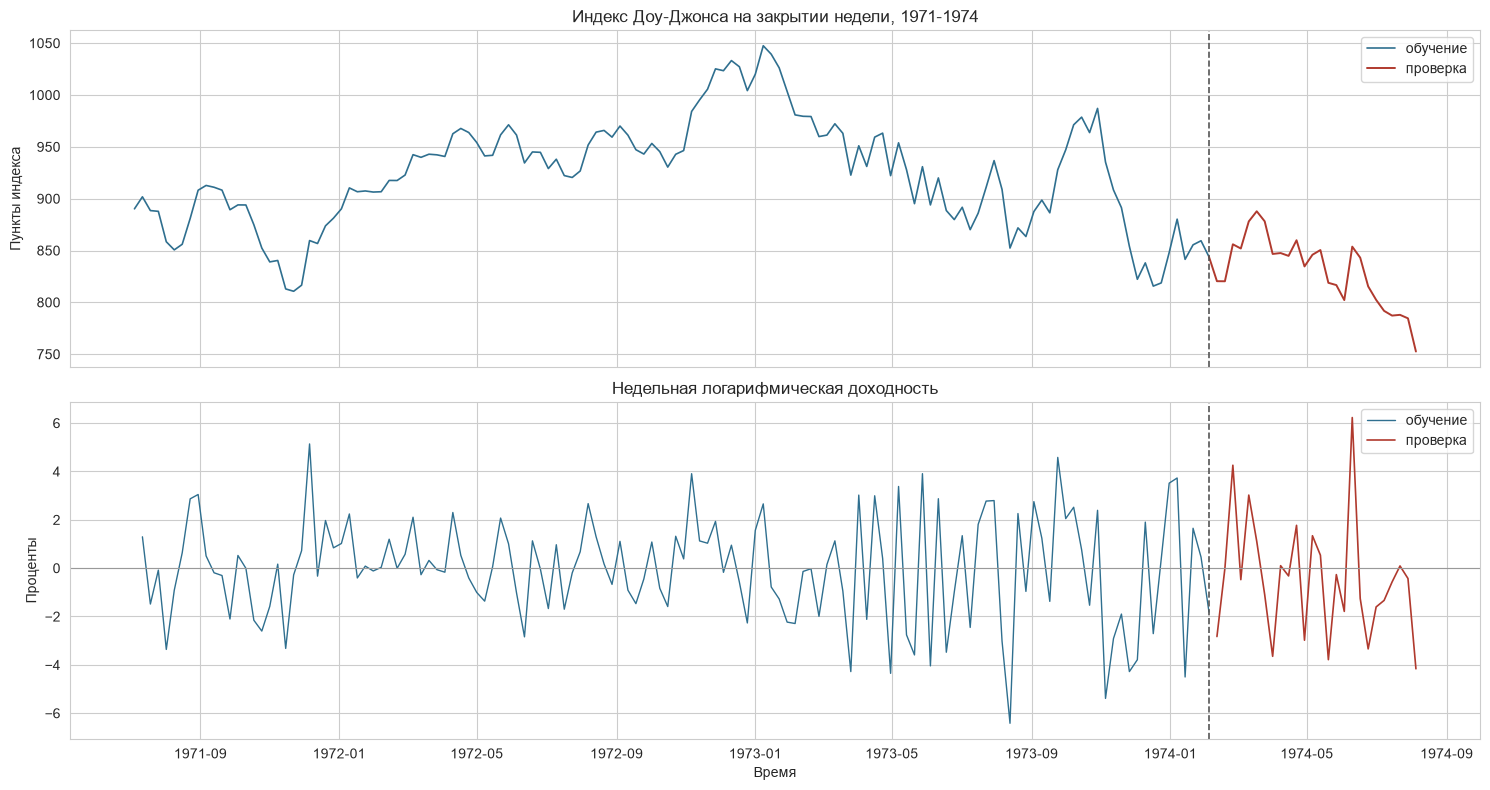

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(цена.index[:-ГОРИЗОНТ], цена.values[:-ГОРИЗОНТ], color='#2f6f8f', linewidth=1.2, label='обучение')
axes[0].plot(цена.index[-ГОРИЗОНТ - 1:], цена.values[-ГОРИЗОНТ - 1:], color='#b03a2e', linewidth=1.4, label='проверка')
axes[0].axvline(обуч.index[-1], color='#555555', linestyle='--', linewidth=1.2)
axes[0].set_title('Индекс Доу-Джонса на закрытии недели, 1971-1974')
axes[0].set_ylabel('Пункты индекса')
axes[0].legend()

axes[1].plot(обуч.index, обуч.values, color='#2f6f8f', linewidth=1.0, label='обучение')
axes[1].plot(тест.index, тест.values, color='#b03a2e', linewidth=1.2, label='проверка')
axes[1].axhline(0, color='#999999', linewidth=0.8)
axes[1].axvline(обуч.index[-1], color='#555555', linestyle='--', linewidth=1.2)
axes[1].set_title('Недельная логарифмическая доходность')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Проценты')
axes[1].legend()

plt.tight_layout()
plt.show()

**Вывод по Задаче 1:**

Ряд целый: **162 недели подряд** без дыр в календаре и без пропусков значений, с 5 июля 1971
по 5 августа 1974 года. Индекс идет от 890 пунктов, поднимается до максимума **1047.49**
в январе 1973 года и заканчивает на **752.58** - это **28.2%** падения от вершины.

**Уровень ряда для моделей этого занятия неинтересен, интересна его изменчивость.** На нижнем
графике видно то, ради чего ARCH и GARCH придуманы: колебания недельной доходности в 1971-1972
годах умещаются в узкую полосу, а с весны 1973 года полоса расширяется примерно вдвое и такой
и остается.

Это не впечатление от картинки, а замер. Разброс доходности по четвертям обучающей части
идет **1.769, 1.300, 2.455, 2.915** процента: первая половина спокойнее второй почти вдвое.
Критерий Левене на равенство дисперсий двух половин дает **p-value 0.000001** - гипотеза
о постоянном разбросе отвергается уверенно.

Разделение выборок сделано по времени: **135 недель** на обучение, **26 недель** (полгода,
с 11 февраля по 5 августа 1974 года) на проверку. Проверочный отрезок целиком лежит в бурном
периоде, и это делает проверку честной в неудобную сторону: модель, обученная в основном
на спокойных данных, должна справиться с бурными

### Задача 2. Приведение ряда к стационарному виду

Задание отдельно подчеркивает, что GARCH работает только со стационарным рядом. Сам индекс
стационарным быть не может: у цены нет уровня, к которому она возвращается, ее приращения
накапливаются. Обычное лекарство - перейти к приращениям, и для цен берут не простую разность,
а разность логарифмов: изменение на десять пунктов значит разное при индексе 750 и при 1050,
а логарифмическая разность измеряет **относительное** изменение и от уровня не зависит.

Проверим три ряда сразу: исходную цену, простую разность и логарифмическую доходность.
Тест **Дики-Фуллера** ищет единичный корень, его нулевая гипотеза - нестационарность;
тест **KPSS** устроен зеркально, в нулевой гипотезе у него стационарность. Число лагов
в ADF выбирается по BIC: он сильнее штрафует лишние параметры, а каждый лишний лаг стоит
одного наблюдения

In [4]:
def проверка(x, имя):
    """два теста стационарности и первая автокорреляция для одного ряда"""
    x = pd.Series(x).dropna()
    а = adfuller(x, autolag='BIC')
    # KPSS берет p-value из таблицы и за ее краем возвращает граничное значение, предупреждая
    # об этом. Ловим предупреждение по месту, чтобы в таблице стояло «>0.1», а не выглядящее
    # посчитанным 0.1
    with warnings.catch_warnings(record=True) as поймано:
        warnings.simplefilter('always')
        к = kpss(x, regression='c', nlags='auto')
    за_краем = any('outside of the range' in str(п.message) for п in поймано)
    p_kpss = ('>0.1' if к[1] > 0.05 else '<0.01') if за_краем else '%.4f' % к[1]
    з = acf(x, nlags=2)
    return {'ряд': имя, 'точек': len(x), 'ADF статистика': round(а[0], 3),
            'ADF p-value': round(а[1], 4), 'KPSS p-value': p_kpss,
            'ACF(1)': round(з[1], 3), 'разброс': round(x.std(ddof=1), 3)}


# все проверки - только по обучающей части ряда
цена_обуч = цена[:len(обуч) + 1]
таблица = pd.DataFrame([
    проверка(цена_обуч, 'индекс, как есть'),
    проверка(цена_обуч.diff(), 'простая разность'),
    проверка(100 * np.log(цена_обуч).diff(), 'логарифмическая доходность, %'),
])
таблица

,ряд,точек,ADF статистика,ADF p-value,KPSS p-value,ACF(1),разброс
0,"индекс, как есть",136,-1.981,0.295,0.0904,0.921,52.880
1,простая разность,135,-11.935,0.000,>0.1,-0.039,19.766
2,"логарифмическая доходность, %",135,-11.934,0.000,>0.1,-0.039,2.172


In [5]:
# у простой разности разброс должен зависеть от уровня индекса, у логарифмической - нет.
# Проверяем прямо: делим обучающую часть пополам по времени и сравниваем разбросы
простая = цена_обуч.diff().dropna()
лог = (100 * np.log(цена_обуч).diff()).dropna()

for имя, ряд_ in [('простая разность', простая), ('логарифмическая доходность', лог)]:
    п1, п2 = np.array_split(ряд_.values, 2)
    print('%-28s разброс: первая половина %.3f, вторая %.3f, отношение %.2f'
          % (имя, np.std(п1, ddof=1), np.std(п2, ddof=1), np.std(п2, ddof=1) / np.std(п1, ddof=1)))

print('\nсредний уровень индекса: первая половина %.1f, вторая %.1f'
      % (цена_обуч.iloc[:len(цена_обуч) // 2].mean(), цена_обуч.iloc[len(цена_обуч) // 2:].mean()))

# проверка того, что разница между двумя разностями - это ровно уровень индекса:
# делим простую разность на вчерашний уровень и смотрим, что получилось
приведенная = (100 * простая / цена_обуч.shift(1)).dropna()
п1, п2 = np.array_split(приведенная.values, 2)
print('простая разность, поделенная на уровень: отношение разбросов по половинам %.2f,'
      ' корреляция с логарифмической доходностью %.5f'
      % (np.std(п2, ddof=1) / np.std(п1, ddof=1), приведенная.corr(лог)))

print('\nраспределение доходности: асимметрия %.3f, избыточный куртозис %.3f'
      % (stats.skew(обуч), stats.kurtosis(обуч)))
print('критерий Шапиро-Уилка на нормальность: p-value %.4f' % stats.shapiro(обуч)[1])

простая разность             разброс: первая половина 13.764, вторая 24.460, отношение 1.78
логарифмическая доходность   разброс: первая половина 1.541, вторая 2.671, отношение 1.73

средний уровень индекса: первая половина 913.6, вторая 931.1
простая разность, поделенная на уровень: отношение разбросов по половинам 1.72, корреляция с логарифмической доходностью 0.99989

распределение доходности: асимметрия -0.267, избыточный куртозис -0.075
критерий Шапиро-Уилка на нормальность: p-value 0.7084


**Вывод по Задаче 2:**

**Индекс нестационарен, но два теста здесь расходятся, и это надо назвать честно.** ADF дает
статистику **-1.981** и p-value **0.295**: гипотезу о единичном корне отвергнуть нельзя.
А KPSS дает **0.0904** - на уровне 5% он тоже не отвергает свою нулевую гипотезу, то есть
формально не спорит со стационарностью. Так бывает на коротких рядах: 136 недель мало обоим
тестам, и каждый остается при своей нулевой гипотезе.

Решает дело не тест, а автокорреляция: у индекса **ACF(1) = 0.921**, затухание медленное,
разброс **52.88** пункта при среднем уровне около девятисот. Ряд, у которого сегодняшнее
значение на 92% предсказано вчерашним, стационарным считать нельзя.

**Обе разности стационарны, и тут тесты согласны.** ADF дает p-value **0.0000** и статистику
около **-11.9**, KPSS - **>0.1** (это не посчитанное число, а верх таблицы критических значений,
дальше тест не различает). Автокорреляция первого лага уходит в **-0.039**, то есть накопления
не осталось.

**Из двух разностей взята логарифмическая, и вот замер, который это оправдывает.** Разброс
простой разности между половинами обучающей части растет в **1.78** раза, логарифмической -
в **1.73**. Разница между ними целиком объясняется уровнем: он за то же время поднялся
с **913.6** до **931.1** пункта. Если простую разность поделить на вчерашний уровень индекса,
получается ряд с корреляцией **0.99989** с логарифмической доходностью и почти тем же
отношением разбросов - **1.72**. То есть простая разность мерит изменчивость вперемешку с уровнем,
а логарифмическая - отдельно от него, и для модели дисперсии нужна вторая.

**Распределение доходности почти нормальное, и это неожиданно.** У недельных финансовых рядов
обычно тяжелые хвосты, здесь же избыточный куртозис **-0.075**, асимметрия **-0.267**,
а критерий Шапиро-Уилка дает **p-value 0.7084** - от нормального распределения отличить
не удается

### Задача 3. Есть ли что моделировать: проверка ARCH-эффекта

Модель GARCH описывает не сам ряд, а его условную дисперсию: сегодняшний разброс зависит
от вчерашних отклонений и от вчерашнего разброса. Строить ее имеет смысл, только если такая
зависимость в данных есть.

Проверяемый признак прост и нагляден: у самой доходности автокорреляция должна отсутствовать
(иначе движение цены было бы предсказуемо), а у ее **квадратов** - присутствовать. Квадрат
доходности - грубая мера того, насколько сильным было движение недели независимо от знака,
и если сильные недели идут подряд, автокорреляция квадратов это покажет.

Посмотрим на обе коррелограммы, проверим их критерием Льюнга-Бокса, а заодно прогоним
специальный тест на ARCH-эффект - множители Лагранжа на регрессии квадрата доходности
по его собственным лагам

In [6]:
# коррелограммы считаются по обучающей части. Полоса значимости приближенная, +-1.96/sqrt(n)
полоса = 1.96 / np.sqrt(len(обуч))
acf_r = acf(обуч, nlags=12)[1:]
acf_r2 = acf(обуч ** 2, nlags=12)[1:]
acf_abs = acf(обуч.abs(), nlags=12)[1:]

коррелограммы = pd.DataFrame({'лаг': np.arange(1, 13),
                              'ACF доходности': np.round(acf_r, 3),
                              'ACF квадратов': np.round(acf_r2, 3),
                              'ACF модулей': np.round(acf_abs, 3)}).set_index('лаг')
print('полоса значимости +-%.3f' % полоса)
print(коррелограммы.to_string())
print('\nлагов за полосой: у доходности %d, у квадратов %d, у модулей %d'
      % ((np.abs(acf_r) > полоса).sum(), (np.abs(acf_r2) > полоса).sum(), (np.abs(acf_abs) > полоса).sum()))

полоса значимости +-0.169
     ACF доходности  ACF квадратов  ACF модулей
лаг                                            
1            -0.039          0.187        0.236
2             0.047          0.095        0.177
3             0.103          0.225        0.303
4            -0.172          0.096        0.175
5             0.091          0.157        0.279
6            -0.161          0.253        0.200
7            -0.092          0.103        0.192
8            -0.029          0.162        0.250
9            -0.203          0.196        0.271
10            0.103          0.186        0.215
11           -0.179          0.092        0.138
12            0.095          0.237        0.189

лагов за полосой: у доходности 3, у квадратов 6, у модулей 11


In [7]:
# критерий Льюнга-Бокса: есть ли автокорреляция хоть на одном из первых k лагов
лб = pd.DataFrame({
    'лагов': [4, 8, 12],
    'p-value доходности': acorr_ljungbox(обуч, lags=[4, 8, 12])['lb_pvalue'].round(4).values,
    'p-value квадратов': acorr_ljungbox(обуч ** 2, lags=[4, 8, 12])['lb_pvalue'].round(4).values,
}).set_index('лагов')
print(лб.to_string())

# тест на ARCH-эффект берется из statsmodels, отдельного пакета для него не нужно
print('\nтест множителей Лагранжа на ARCH-эффект (по доходности):')
for л in (1, 2, 4, 8, 12):
    статистика, p, _, _ = het_arch(обуч, nlags=л)
    print('  лагов %2d: LM %6.3f, p-value %.4f' % (л, статистика, p))

       p-value доходности  p-value квадратов
лагов                                       
4                  0.1878             0.0059
8                  0.1349             0.0001
12                 0.0102             0.0000

тест множителей Лагранжа на ARCH-эффект (по доходности):
  лагов  1: LM  4.683, p-value 0.0305
  лагов  2: LM  5.103, p-value 0.0780
  лагов  4: LM 10.907, p-value 0.0276
  лагов  8: LM 17.703, p-value 0.0236
  лагов 12: LM 22.920, p-value 0.0284


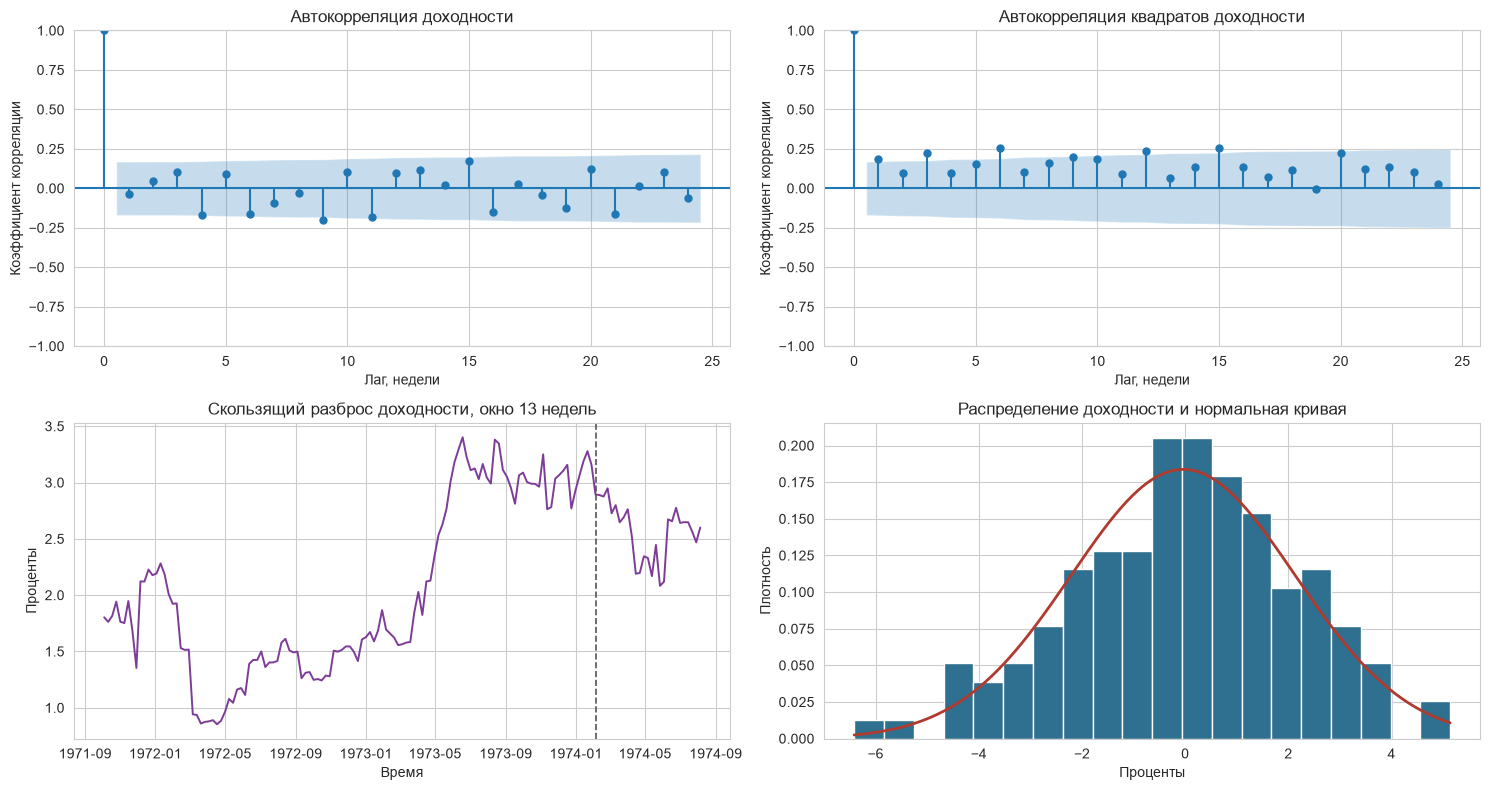

скользящий разброс: от 0.853 до 3.402, отношение 3.99
из десяти самых крупных недельных движений ряда пришлось на 1973-1974 годы: 9


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

plot_acf(обуч, lags=24, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('Автокорреляция доходности')
axes[0, 0].set_xlabel('Лаг, недели')
axes[0, 0].set_ylabel('Коэффициент корреляции')

plot_acf(обуч ** 2, lags=24, ax=axes[0, 1], alpha=0.05)
axes[0, 1].set_title('Автокорреляция квадратов доходности')
axes[0, 1].set_xlabel('Лаг, недели')
axes[0, 1].set_ylabel('Коэффициент корреляции')

# скользящий разброс по окну в квартал: как меняется изменчивость во времени
скольз = доходность.rolling(13).std(ddof=1)
axes[1, 0].plot(скольз.index, скольз.values, color='#7d3c98', linewidth=1.4)
axes[1, 0].axvline(обуч.index[-1], color='#555555', linestyle='--', linewidth=1.2)
axes[1, 0].set_title('Скользящий разброс доходности, окно 13 недель')
axes[1, 0].set_xlabel('Время')
axes[1, 0].set_ylabel('Проценты')

axes[1, 1].hist(обуч.values, bins=20, color='#2f6f8f', edgecolor='white', density=True)
сетка = np.linspace(обуч.min(), обуч.max(), 200)
axes[1, 1].plot(сетка, stats.norm.pdf(сетка, обуч.mean(), обуч.std(ddof=1)), color='#b03a2e', linewidth=2)
axes[1, 1].set_title('Распределение доходности и нормальная кривая')
axes[1, 1].set_xlabel('Проценты')
axes[1, 1].set_ylabel('Плотность')

plt.tight_layout()
plt.show()

print('скользящий разброс: от %.3f до %.3f, отношение %.2f'
      % (скольз.min(), скольз.max(), скольз.max() / скольз.min()))
крупные = доходность.abs().nlargest(10)
print('из десяти самых крупных недельных движений ряда пришлось на 1973-1974 годы: %d'
      % (крупные.index.year >= 1973).sum())

**Вывод по Задаче 3:**

**У самой доходности автокорреляция слабая.** Из двенадцати лагов за полосу значимости
**+-0.169** выходит три (четвертый, девятый и одиннадцатый, все отрицательные), первый лаг
всего **-0.039**. Льюнг-Бокс не находит зависимости ни на четырех лагах (**p-value 0.1878**),
ни на восьми (**0.1349**), и лишь на двенадцати выходит за порог (**0.0102**). Для предсказания
уровня это почти белый шум, чего от цены акций и ждешь, но совсем пустой модель среднего
не будет.

**У квадратов картина заметно сильнее.** Автокорреляция квадратов на первом лаге **0.187**,
за полосу выходит **шесть** лагов из двенадцати, а у модулей доходности - **одиннадцать
из двенадцати**. Льюнг-Бокс по квадратам отвергает независимость на всех трех глубинах:
**p-value 0.0059, 0.0001, 0.0000**. Специальный тест на ARCH-эффект отвергает гипотезу
постоянной дисперсии на первом лаге (**p-value 0.0305**) и держит отказ до двенадцатого
(**0.0284**).

Разница между двумя коррелограммами и есть суть ARCH-эффекта: **знак** движения предсказать
нельзя, а **размах** - можно.

**Скользящий разброс показывает то же самое крупным планом.** По окну в квартал он гуляет
от **0.853%** до **3.402%**, то есть вчетверо, причем не хаотично: низкие значения собраны
в 1972 году, высокие - в 1973-1974. **Девять** из десяти самых крупных недельных движений
всего ряда приходятся на эти два года.

Значит, ARCH-эффект в ряде есть, и модель условной дисперсии здесь оправдана. Но полезно
заметить сразу, какого он вида: сильнее всего он проявляется не на первом лаге, а как медленный
сдвиг уровня изменчивости между спокойным и бурным периодами

### Задача 4. Подбор оптимальных параметров ARIMA

По условию параметры ARIMA подбираются так же, как в лекционном ноутбуке: перебором по сетке
порядков с выбором минимума информационного критерия Акаике.

Порядок дифференцирования `d` перебору не отдается. Он отвечает на вопрос о природе ряда,
и ответ уже получен в Задаче 2: логарифмическая доходность - это и есть однократная разность
логарифма индекса, дальше дифференцировать нечего. Поэтому сетка идет по `p` и `q` от 0 до 4
при `d = 0`, ровно 25 моделей.

Но сначала стоит посмотреть на коррелограммы уже стационарного ряда. У авторегрессии
порядка `p` частная автокорреляция обрывается после лага `p`, а обычная затухает плавно;
у скользящего среднего порядка `q` наоборот - обрывается обычная. Если картинка порядок
называет, перебор ее подтверждает; если затухают обе, порядок придется назвать перебором.

Отдельно проверим саму модель-победителя, а не только значение критерия у нее. У ARMA есть
неприятное свойство: авторегрессионный и скользящий множители могут почти сократить друг
друга, и тогда модель с восемью параметрами описывает то же, что модель без параметров,
но выглядит по критерию лучше. Признак такого сокращения - близкие корни у обоих
многочленов и коэффициенты, неотличимые от нуля

полоса значимости +-0.169
       ACF   PACF
лаг              
1   -0.039 -0.039
2    0.047  0.045
3    0.103  0.106
4   -0.172 -0.168
5    0.091  0.073
6   -0.161 -0.158
7   -0.092 -0.073
8   -0.029 -0.069
9   -0.203 -0.153
10   0.103  0.063
11  -0.179 -0.181
12   0.095  0.108

за полосой: ACF на лагах [4, 9, 11], PACF на лагах [11]
на первых трех лагах максимум по модулю: ACF 0.103, PACF 0.106


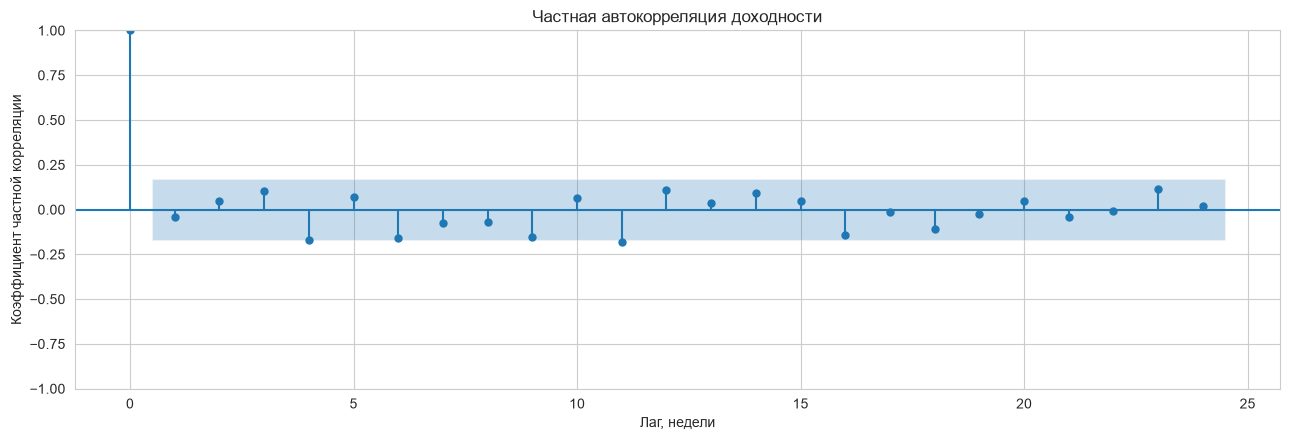

In [9]:
# порядок сначала читается по коррелограммам стационарного ряда. Полоса значимости
# приближенная, +-1.96/sqrt(n). Метод PACF задан явно: у pacf() умолчание
# 'ywadjusted', у plot_pacf() - 'ywm', и на этом коротком ряде они расходятся
# настолько, что вердикт о значимости лага 4 у них разный. Берем 'ywm', чтобы
# таблица и график ниже говорили одно и то же
полоса_обуч = 1.96 / np.sqrt(len(обуч))
лаги = np.arange(1, 13)
acf_обуч = acf(обуч, nlags=12)[1:]
pacf_обуч = pacf(обуч, nlags=12, method='ywm')[1:]

корр = pd.DataFrame({'лаг': лаги, 'ACF': np.round(acf_обуч, 3),
                     'PACF': np.round(pacf_обуч, 3)}).set_index('лаг')
print('полоса значимости +-%.3f' % полоса_обуч)
print(корр.to_string())
print('\nза полосой: ACF на лагах %s, PACF на лагах %s'
      % (list(map(int, лаги[np.abs(acf_обуч) > полоса_обуч])),
         list(map(int, лаги[np.abs(pacf_обуч) > полоса_обуч]))))
print('на первых трех лагах максимум по модулю: ACF %.3f, PACF %.3f'
      % (np.abs(acf_обуч[:3]).max(), np.abs(pacf_обуч[:3]).max()))

fig, ax = plt.subplots(figsize=(13, 4.5))
plot_pacf(обуч, lags=24, ax=ax, alpha=0.05, method='ywm')
ax.set_title('Частная автокорреляция доходности')
ax.set_xlabel('Лаг, недели')
ax.set_ylabel('Коэффициент частной корреляции')
plt.tight_layout()
plt.show()

In [10]:
# сетка 5x5 по p и q при d = 0, как в лекционном ноутбуке, но с явным maxiter:
# по умолчанию SARIMAX делает 50 итераций, и на части порядков этого не хватает
результаты = []
for p_ in range(5):
    for q_ in range(5):
        модель = ARIMA(обуч, order=(p_, 0, q_), trend='c').fit(method_kwargs={'maxiter': 500})
        результаты.append({'p': p_, 'q': q_, 'AIC': модель.aic, 'BIC': модель.bic,
                           'логправдоподобие': модель.llf, 'модель': модель})

сетка_aic = pd.DataFrame(index=['p=%d' % i for i in range(5)],
                         columns=['q=%d' % j for j in range(5)], dtype=float)
for р in результаты:
    сетка_aic.iloc[р['p'], р['q']] = round(р['AIC'], 2)
print('AIC по сетке порядков:')
print(сетка_aic.to_string())

по_aic = sorted(результаты, key=lambda р: р['AIC'])
по_bic = sorted(результаты, key=lambda р: р['BIC'])
print('\nминимум AIC: ARIMA(%d,0,%d), AIC %.3f' % (по_aic[0]['p'], по_aic[0]['q'], по_aic[0]['AIC']))
print('минимум BIC: ARIMA(%d,0,%d), BIC %.3f' % (по_bic[0]['p'], по_bic[0]['q'], по_bic[0]['BIC']))
print('\nпятерка лучших по AIC:')
for р in по_aic[:5]:
    print('  ARIMA(%d,0,%d)  AIC %8.3f  BIC %8.3f  логправдоподобие %8.3f'
          % (р['p'], р['q'], р['AIC'], р['BIC'], р['логправдоподобие']))

AIC по сетке порядков:
        q=0     q=1     q=2     q=3     q=4
p=0  595.48  597.29  598.71  599.39  598.35
p=1  597.27  597.25  600.10  598.94  599.86
p=2  598.99  600.79  589.93  591.54  599.59
p=3  599.46  597.31  603.22  593.27  593.27
p=4  597.36  597.46  597.72  592.97  586.68

минимум AIC: ARIMA(4,0,4), AIC 586.678
минимум BIC: ARIMA(0,0,0), BIC 601.288

пятерка лучших по AIC:
  ARIMA(4,0,4)  AIC  586.678  BIC  615.731  логправдоподобие -283.339
  ARIMA(2,0,2)  AIC  589.930  BIC  607.361  логправдоподобие -288.965
  ARIMA(2,0,3)  AIC  591.538  BIC  611.875  логправдоподобие -288.769
  ARIMA(4,0,3)  AIC  592.972  BIC  619.120  логправдоподобие -287.486
  ARIMA(3,0,4)  AIC  593.267  BIC  619.414  логправдоподобие -287.633


In [11]:
def разбор(модель, имя):
    """смотрим на саму модель, а не только на критерий: корни и значимость коэффициентов"""
    print('=== %s ===' % имя)
    print('AIC %.3f, BIC %.3f, логправдоподобие %.3f' % (модель.aic, модель.bic, модель.llf))
    if len(модель.arroots):
        print('модули корней AR:', np.round(np.abs(модель.arroots), 3))
    if len(модель.maroots):
        print('модули корней MA:', np.round(np.abs(модель.maroots), 3))
    таб = pd.DataFrame({'оценка': модель.params.round(4), 'p-value': модель.pvalues.round(4)})
    print(таб.to_string())
    print('коэффициентов с p-value больше 0.05: %d из %d\n'
          % (int((модель.pvalues > 0.05).sum()), len(модель.pvalues)))


разбор(по_aic[0]['модель'], 'ARIMA(%d,0,%d) - минимум AIC' % (по_aic[0]['p'], по_aic[0]['q']))
разбор(по_aic[1]['модель'], 'ARIMA(%d,0,%d) - второе место по AIC' % (по_aic[1]['p'], по_aic[1]['q']))

=== ARIMA(4,0,4) - минимум AIC ===
AIC 586.678, BIC 615.731, логправдоподобие -283.339
модули корней AR: [1.046 1.046 1.013 1.013]
модули корней MA: [1.    1.    1.108 1.108]
        оценка  p-value
const  -0.0463   0.8266
ar.L1   0.1250   0.1414
ar.L2   0.8308   0.0000
ar.L3   0.0184   0.7920
ar.L4  -0.8922   0.0000
ma.L1  -0.1323   0.9638
ma.L2  -0.8276   0.4650
ma.L3   0.1814   0.9518
ma.L4   0.8137   0.7714
sigma2  3.7438   0.7721
коэффициентов с p-value больше 0.05: 8 из 10

=== ARIMA(2,0,2) - второе место по AIC ===
AIC 589.930, BIC 607.361, логправдоподобие -288.965
модули корней AR: [1.049 1.049]
модули корней MA: [1.074 1.074]
        оценка  p-value
const  -0.0365   0.8424
ar.L1  -1.6159   0.0000
ar.L2  -0.9080   0.0000
ma.L1   1.6494   0.0000
ma.L2   0.8669   0.0000
sigma2  4.2100   0.0000
коэффициентов с p-value больше 0.05: 1 из 6



In [12]:
# сокращение множителей проверяется прямо: если корень AR совпал с корнем MA,
# соответствующая пара в модели друг друга гасит
победитель = по_aic[0]['модель']
ar_корни = np.sort_complex(победитель.arroots)
ma_корни = np.sort_complex(победитель.maroots)
print('корни AR:', np.round(ar_корни, 3))
print('корни MA:', np.round(ma_корни, 3))
print('расстояние от каждого корня AR до ближайшего корня MA:',
      np.round([np.min(np.abs(ma_корни - к)) for к in ar_корни], 3))
print('минимальный модуль корня MA %.4f (единица - граница обратимости)' % np.abs(ma_корни).min())

корни AR: [-0.868-0.583j -0.868+0.583j  0.878-0.504j  0.878+0.504j]
корни MA: [-0.958-0.557j -0.958+0.557j  0.847-0.532j  0.847+0.532j]
расстояние от каждого корня AR до ближайшего корня MA: [0.094 0.094 0.043 0.043]
минимальный модуль корня MA 1.0003 (единица - граница обратимости)


In [13]:
# сверка своего перебора с готовым подборщиком: совпал порядок - подтверждение,
# разошелся - повод разобраться, у кого границы перебора и критерий устроены иначе
try:
    import pmdarima as pm
except ImportError:
    !pip install -q pmdarima
    import pmdarima as pm

print('число разностей по тестам pmdarima: у индекса %d, у доходности %d'
      % (pm.arima.ndiffs(цена_обуч.values, test='kpss'), pm.arima.ndiffs(обуч.values, test='kpss')))

for критерий in ('aic', 'bic'):
    авто = pm.auto_arima(обуч.values, seasonal=False, d=0, information_criterion=критерий,
                         max_p=4, max_q=4, stepwise=False, maxiter=500,
                         suppress_warnings=True, error_action='ignore')
    print('auto_arima по %s: порядок %s, AIC %.3f, BIC %.3f'
          % (критерий.upper(), авто.order, авто.aic(), авто.bic()))

число разностей по тестам pmdarima: у индекса 1, у доходности 0


auto_arima по AIC: порядок (2, 0, 2), AIC 587.972, BIC 602.499


auto_arima по BIC: порядок (0, 0, 0), AIC 593.522, BIC 596.428


In [14]:
# для среднего берем ARIMA(2,0,2): по AIC она вторая, зато все ее коэффициенты значимы,
# а корни AR и MA не сокращаются
средняя = [р for р in результаты if р['p'] == 2 and р['q'] == 2][0]['модель']
белый_шум = [р for р in результаты if р['p'] == 0 and р['q'] == 0][0]['модель']

сравнение = pd.DataFrame({
    'модель': ['ARIMA(4,0,4) - минимум AIC', 'ARIMA(2,0,2) - выбранная', 'ARIMA(0,0,0) - минимум BIC'],
    'AIC': [round(по_aic[0]['AIC'], 2), round(средняя.aic, 2), round(белый_шум.aic, 2)],
    'BIC': [round(по_aic[0]['BIC'], 2), round(средняя.bic, 2), round(белый_шум.bic, 2)],
    'параметров': [len(по_aic[0]['модель'].params), len(средняя.params), len(белый_шум.params)],
    'незначимых': [int((по_aic[0]['модель'].pvalues > 0.05).sum()),
                   int((средняя.pvalues > 0.05).sum()), int((белый_шум.pvalues > 0.05).sum())],
})
сравнение

,модель,AIC,BIC,параметров,незначимых
0,"ARIMA(4,0,4) - минимум AIC",586.68,615.73,10,8
1,"ARIMA(2,0,2) - выбранная",589.93,607.36,6,1
2,"ARIMA(0,0,0) - минимум BIC",595.48,601.29,2,1


**Вывод по Задаче 4:**

**Коррелограмма порядок не называет, и это ожидаемо.** Ни одна из двух функций не
обрывается: на первых трех лагах обе лежат внутри полосы **+-0.169** (максимум по модулю
**0.103** у ACF и **0.106** у PACF), а за полосу выходят разрозненные далекие лаги -
ACF на **4, 9 и 11** (**-0.172, -0.203, -0.179**), PACF только на **11** (**-0.181**).
Ни обрыва после малого лага, ни плавного затухания: это картина ряда, близкого к белому
шуму, ровно та, что получилась в Задаче 3. Значит, порядок здесь называется перебором,
а не по картинке.

**Минимум AIC достался ARIMA(4,0,4) - и брать его нельзя.** Значение критерия у нее **586.68**
против 589.93 у следующей модели, но сама модель разваливается при первом же взгляде.
Из десяти ее оценок **восемь** имеют p-value больше 0.05, в том числе дисперсия шума (0.772)
и три из четырех коэффициентов скользящего среднего. Модули корней скользящего многочлена
равны **1.000** (точнее, минимальный **1.0003**) - это в точности граница обратимости, дальше
которой модель перестает быть определенной однозначно.

**Причина видна на самих корнях, и это не догадка, а замер.** Каждый корень AR отстоит
от ближайшего корня MA на **0.094 и 0.043** при том, что сами корни лежат на расстоянии
больше единицы от нуля. То есть авторегрессионный и скользящий множители почти сокращают
друг друга: восемь параметров описывают примерно то же, что не описывает ничего. Выигрыш
в три пункта AIC куплен именно этим.

**BIC, который штрафует параметры сильнее, выбирает ARIMA(0,0,0)**, то есть чистый белый шум
с константой. Это согласуется с Задачей 3, где автокорреляция доходности нашлась, но слабая.

**Готовый подборщик подтверждает выбор.** `auto_arima` при полном переборе останавливается
по AIC на **ARIMA(2,0,2)**, по BIC - на **ARIMA(0,0,0)**. Число разностей его тесты берут
те же: **1** для индекса и **0** для доходности. Значение AIC у него на том же порядке
получается **587.97** против 589.93 в моей сетке - расходятся не модели, а сходимость
оптимизации, поэтому в одну таблицу эти числа сводить нельзя.

**Для среднего берется ARIMA(2,0,2).** Все четыре ее коэффициента ARMA значимы с p-value
**0.0000**, незначим только свободный член (0.8424), корни AR и MA различимы по модулю
(**1.049** против **1.074**), а по AIC она вторая с отставанием в три пункта от модели,
которую пришлось отвергнуть

### Задача 5. Остатки модели среднего

GARCH строится не на самом ряде, а на том, что осталось от него после вычитания предсказуемой
части. Логика простая: ARIMA отвечает за уровень, GARCH - за разброс вокруг этого уровня,
и смешивать две задачи не надо.

Значит, надо посмотреть на остатки выбранной ARIMA(2,0,2) и убедиться в двух вещах сразу.
Первое: в остатках не должно остаться автокорреляции - иначе модель среднего недоработала.
Второе: в квадратах остатков автокорреляция как раз должна сохраниться - иначе моделировать
дисперсию будет нечего.

Заодно посмотрим, что стало с ARCH-эффектом у отвергнутой ARIMA(4,0,4): это проверка того,
что она действительно сокращает множители, а не описывает данные

In [15]:
остатки = средняя.resid
отвергнутая = по_aic[0]['модель'].resid

print('остатки ARIMA(2,0,2): %d точек, среднее %.4f, разброс %.4f'
      % (len(остатки), остатки.mean(), остатки.std(ddof=1)))
print('разброс самой доходности обучения %.4f' % обуч.std(ddof=1))

for имя, e in [('ARIMA(2,0,2)', остатки), ('ARIMA(4,0,4)', отвергнутая)]:
    лб_e = acorr_ljungbox(e, lags=[8, 12])['lb_pvalue'].values
    лб_e2 = acorr_ljungbox(e ** 2, lags=[8, 12])['lb_pvalue'].values
    arch_p = [het_arch(e, nlags=л)[1] for л in (1, 4, 8, 12)]
    print('\n%s' % имя)
    print('  Льюнг-Бокс по остаткам (8 и 12 лагов): p-value %.4f, %.4f' % tuple(лб_e))
    print('  Льюнг-Бокс по квадратам остатков:      p-value %.4f, %.4f' % tuple(лб_e2))
    print('  ARCH-эффект на 1, 4, 8, 12 лагах:      p-value %.4f, %.4f, %.4f, %.4f' % tuple(arch_p))
    print('  автокорреляция квадратов на первом лаге %.3f' % acf(e ** 2, nlags=1)[1])

остатки ARIMA(2,0,2): 135 точек, среднее -0.0021, разброс 2.0639
разброс самой доходности обучения 2.1715

ARIMA(2,0,2)
  Льюнг-Бокс по остаткам (8 и 12 лагов): p-value 0.5924, 0.5540
  Льюнг-Бокс по квадратам остатков:      p-value 0.0366, 0.0507
  ARCH-эффект на 1, 4, 8, 12 лагах:      p-value 0.0255, 0.0695, 0.2462, 0.3861
  автокорреляция квадратов на первом лаге 0.193

ARIMA(4,0,4)
  Льюнг-Бокс по остаткам (8 и 12 лагов): p-value 0.9573, 0.9234
  Льюнг-Бокс по квадратам остатков:      p-value 0.5302, 0.5452
  ARCH-эффект на 1, 4, 8, 12 лагах:      p-value 0.1648, 0.3094, 0.5857, 0.7043
  автокорреляция квадратов на первом лаге 0.120


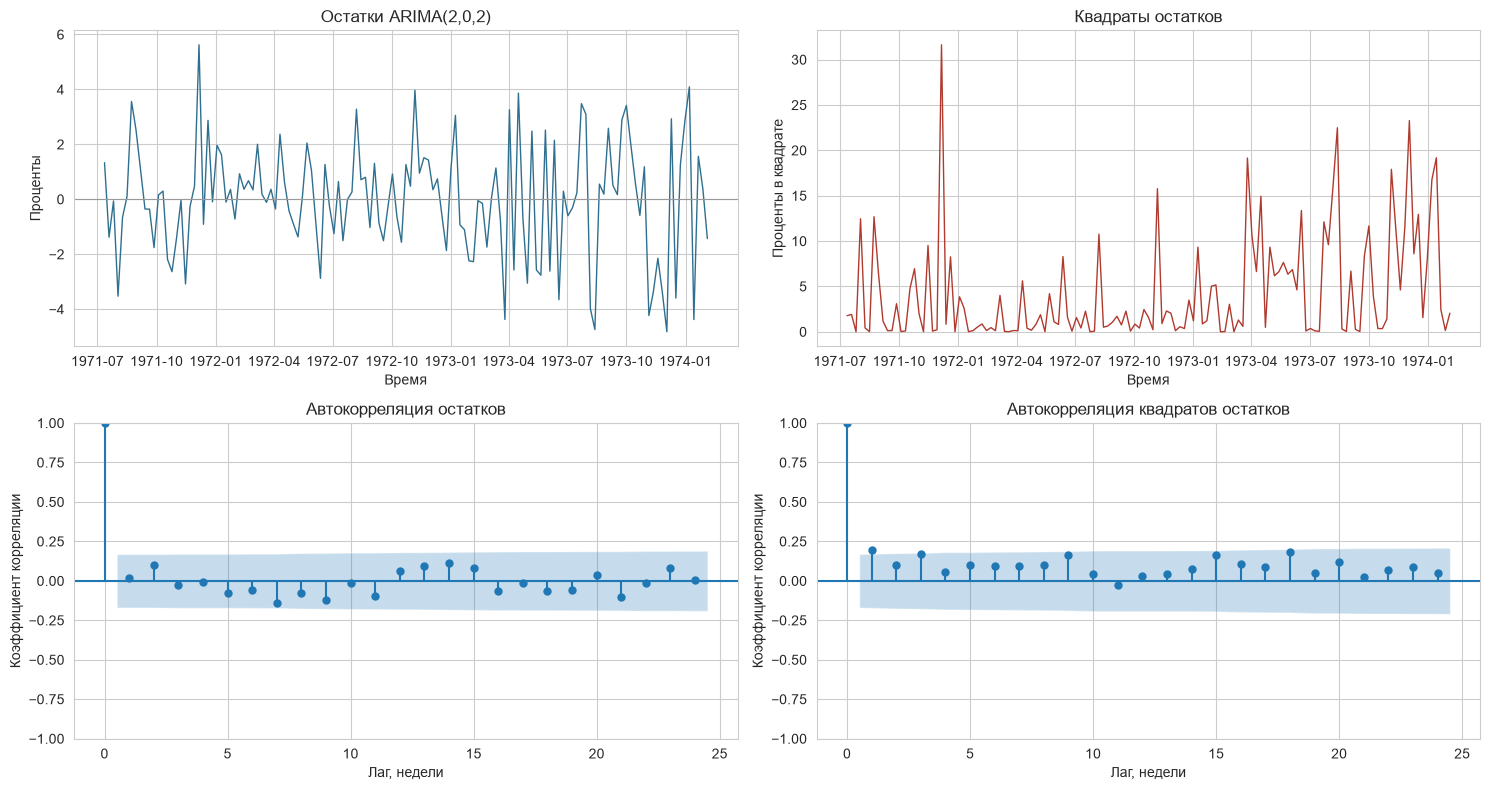

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

axes[0, 0].plot(остатки.index, остатки.values, color='#2f6f8f', linewidth=1.0)
axes[0, 0].axhline(0, color='#999999', linewidth=0.8)
axes[0, 0].set_title('Остатки ARIMA(2,0,2)')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Проценты')

axes[0, 1].plot(остатки.index, (остатки ** 2).values, color='#b03a2e', linewidth=1.0)
axes[0, 1].set_title('Квадраты остатков')
axes[0, 1].set_xlabel('Время')
axes[0, 1].set_ylabel('Проценты в квадрате')

plot_acf(остатки, lags=24, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('Автокорреляция остатков')
axes[1, 0].set_xlabel('Лаг, недели')
axes[1, 0].set_ylabel('Коэффициент корреляции')

plot_acf(остатки ** 2, lags=24, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('Автокорреляция квадратов остатков')
axes[1, 1].set_xlabel('Лаг, недели')
axes[1, 1].set_ylabel('Коэффициент корреляции')

plt.tight_layout()
plt.show()

**Вывод по Задаче 5:**

**Модель среднего свою работу сделала.** Критерий Льюнга-Бокса по остаткам ARIMA(2,0,2) дает
**p-value 0.5924 и 0.5540** на восьми и двенадцати лагах - автокорреляции не осталось.
Разброс остатков **2.064%** против 2.172% у самой доходности: модель сняла около пяти
процентов разброса, что для ряда, близкого к белому шуму, ожидаемо мало.

**А ARCH-эффект в остатках остался.** Тест множителей Лагранжа на первом лаге дает **p-value
0.0255**, Льюнг-Бокс по квадратам остатков - **0.0366** на восьми лагах. Автокорреляция
квадратов на первом лаге **0.193**. Значит, для модели дисперсии есть работа, и это главное
основание строить GARCH. Стоит заметить, что модель среднего этот эффект частично съела:
у самой доходности он был значим на всех глубинах до двенадцатого лага, у остатков держится
только на первом (дальше **0.0695, 0.2462, 0.3861**).

**Отвергнутая ARIMA(4,0,4) ведет себя показательно иначе.** У нее чисто все: и остатки
(p-value 0.9573), и квадраты остатков (**0.5302**), и ARCH-эффект (**0.1648** на первом лаге).
Выглядит как идеальная модель, а на деле это тот самый признак сокращения множителей -
восемь параметров подобрались так, что вобрали в среднее ровно те всплески, которые должна
описывать дисперсия. Если бы она была взята как модель среднего, строить GARCH стало бы
не на чем: сама постановка задачи исчезла бы из данных

### Задача 6. Модель GARCH на найденных параметрах

Теперь на остатках ARIMA(2,0,2) строится модель условной дисперсии. В пакете `arch` порядок
записывается как GARCH(p, q), где `p` - число лагов квадратов остатков (коэффициенты альфа),
а `q` - число лагов самой условной дисперсии (коэффициенты бета). При `q = 0` получается
чистая ARCH.

Найденные параметры ARIMA переносятся в модель дисперсии буквально: порядки среднего
**(2, 2)** дают GARCH(2, 2). Рядом считаются соседние порядки и два распределения ошибок -
нормальное и Стьюдента. Распределение Стьюдента в лекционном ноутбуке взято как обычно
подходящее лучше, и это стоит проверить на своих данных: в Задаче 2 замер показал у этого ряда
избыточный куртозис около нуля, то есть тяжелых хвостов, ради которых Стьюдента и берут, здесь
может не быть

In [17]:
# сетка по порядкам модели дисперсии и по распределению ошибок.
# p = 0 в сетку не берется: без хотя бы одного лага квадратов остатков это уже не ARCH
сетка_garch = []
for p_ in (1, 2):
    for q_ in (0, 1, 2):
        for распр, подпись in [('normal', 'нормальное'), ('t', 'Стьюдента')]:
            м = arch_model(остатки, mean='Zero', vol='GARCH', p=p_, q=q_, dist=распр).fit(disp='off')
            сетка_garch.append({'p': p_, 'q': q_, 'распределение': подпись,
                                'AIC': round(м.aic, 3), 'BIC': round(м.bic, 3),
                                'логправдоподобие': round(м.loglikelihood, 3), 'объект': м})

таб_garch = pd.DataFrame(сетка_garch).drop(columns='объект').sort_values('AIC').reset_index(drop=True)
таб_garch

,p,q,распределение,AIC,BIC,логправдоподобие
0,1,2,нормальное,573.365,584.986,-282.682
1,1,1,нормальное,574.779,583.495,-284.390
2,2,2,нормальное,575.365,589.891,-282.682
3,1,2,Стьюдента,575.367,589.893,-282.683
4,2,1,нормальное,576.694,588.315,-284.347
5,1,1,Стьюдента,576.760,588.381,-284.380
6,1,0,нормальное,577.033,582.844,-286.517
7,2,2,Стьюдента,577.379,594.811,-282.690
8,2,1,Стьюдента,578.686,593.212,-284.343
9,2,0,нормальное,579.011,587.726,-286.505


In [18]:
# буквальный перенос порядков ARIMA(2,0,2) в модель дисперсии и вариант по BIC
garch22 = [с['объект'] for с in сетка_garch if (с['p'], с['q'], с['распределение']) == (2, 2, 'нормальное')][0]
garch11 = [с['объект'] for с in сетка_garch if (с['p'], с['q'], с['распределение']) == (1, 1, 'нормальное')][0]

print(garch22.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.007
Vol Model:                      GARCH   Log-Likelihood:               -282.682
Distribution:                  Normal   AIC:                           575.365
Method:            Maximum Likelihood   BIC:                           589.891
                                        No. Observations:                  135
Date:                Wed, Sep 02 2026   Df Residuals:                      135
Time:                        21:25:58   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1522      0.289      0.527      0.598    [ -

In [19]:
print(garch11.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.007
Vol Model:                      GARCH   Log-Likelihood:               -284.390
Distribution:                  Normal   AIC:                           574.779
Method:            Maximum Likelihood   BIC:                           583.495
                                        No. Observations:                  135
Date:                Wed, Sep 02 2026   Df Residuals:                      135
Time:                        21:25:58   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0806  9.269e-02      0.869      0.385   [ -0.10

In [20]:
# персистентность - сумма альфа и бета: насколько долго живет всплеск дисперсии.
# Чем ближе к единице, тем медленнее модель забывает прошлое
def свойства(м, имя):
    альфа = sum(v for k, v in м.params.items() if k.startswith('alpha'))
    бета = sum(v for k, v in м.params.items() if k.startswith('beta'))
    пер = альфа + бета
    безусл = м.params['omega'] / (1 - пер) if пер < 1 else np.nan
    полураспад = np.log(0.5) / np.log(пер) if 0 < пер < 1 else np.nan
    return {'модель': имя, 'сумма альфа': round(альфа, 4), 'сумма бета': round(бета, 4),
            'персистентность': round(пер, 4), 'безусловная дисперсия': round(безусл, 3),
            'безусловный разброс': round(np.sqrt(безусл), 3),
            'полураспад шока, недель': round(полураспад, 1)}


свод = pd.DataFrame([свойства(garch22, 'GARCH(2,2), порядки от ARIMA'),
                     свойства(garch11, 'GARCH(1,1)')])
print(свод.to_string(index=False))
print('\nвыборочная дисперсия остатков обучения %.3f, разброс %.3f'
      % (остатки.var(ddof=1), остатки.std(ddof=1)))
print('дисперсия остатков в первой половине обучения %.3f, во второй %.3f'
      % (остатки[:len(остатки) // 2].var(ddof=1), остатки[len(остатки) // 2:].var(ddof=1)))

                      модель  сумма альфа  сумма бета  персистентность  безусловная дисперсия  безусловный разброс  полураспад шока, недель
GARCH(2,2), порядки от ARIMA       0.1534      0.8249           0.9784                  7.033                2.652                     31.7
                  GARCH(1,1)       0.0582      0.9291           0.9874                  6.370                2.524                     54.5

выборочная дисперсия остатков обучения 4.260, разброс 2.064
дисперсия остатков в первой половине обучения 2.540, во второй 5.996


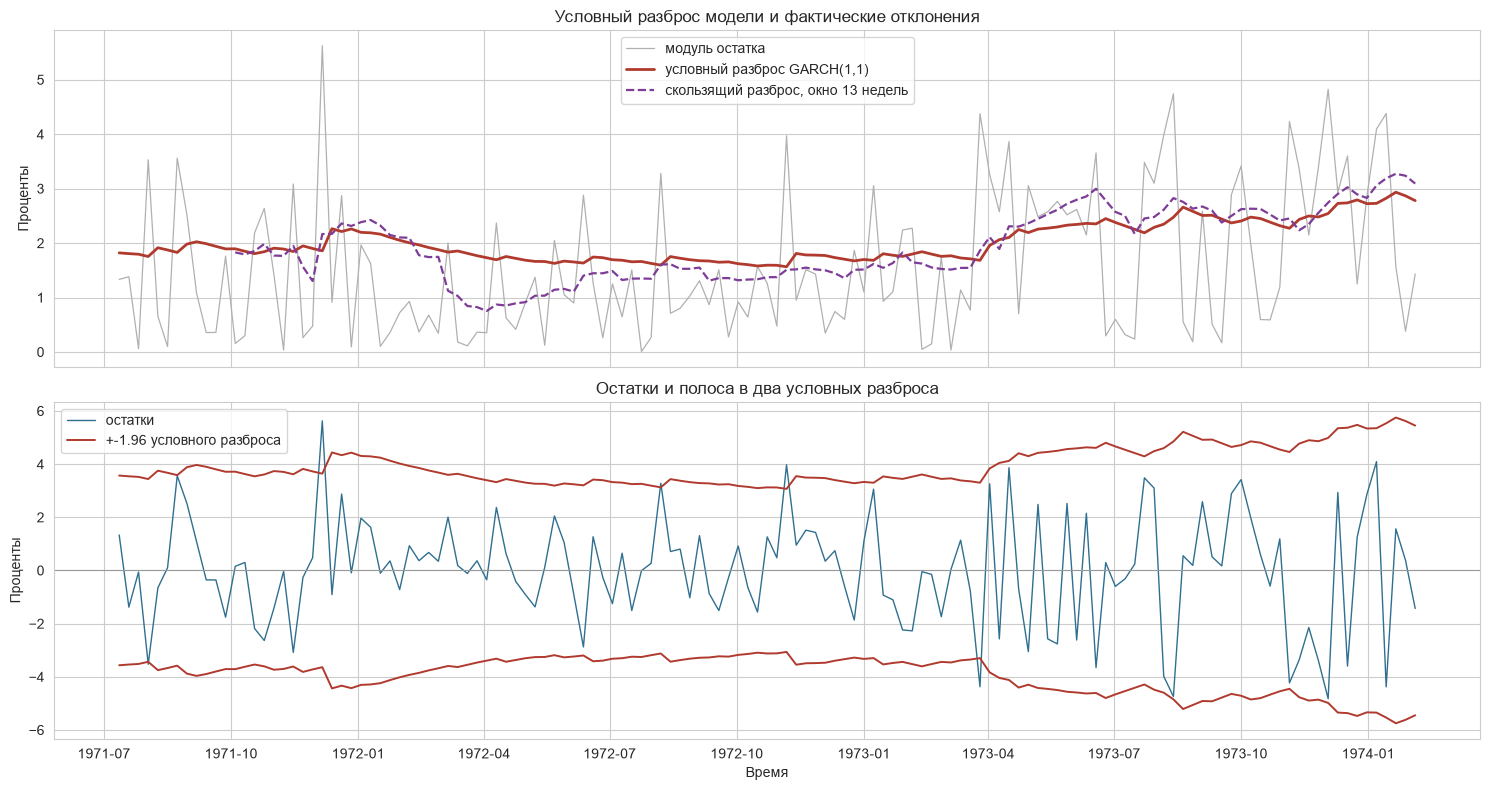

условный разброс GARCH(1,1): от 1.565 до 2.934
корреляция условного разброса со скользящим разбросом 0.924
средний условный разброс в 1972 году 1.755, в 1973 году 2.237
доля остатков вне полосы +-1.96 условного разброса 0.037 (ожидается около 0.05)


In [21]:
# условная волатильность GARCH(1,1) против скользящего разброса: рисуют ли они одно и то же
усл_вол = pd.Series(garch11.conditional_volatility, index=остатки.index)
скольз_обуч = остатки.rolling(13).std(ddof=1)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(остатки.index, остатки.abs().values, color='#b0b0b0', linewidth=0.9, label='модуль остатка')
axes[0].plot(усл_вол.index, усл_вол.values, color='#b03a2e', linewidth=2.0, label='условный разброс GARCH(1,1)')
axes[0].plot(скольз_обуч.index, скольз_обуч.values, color='#7d3c98', linewidth=1.6,
             linestyle='--', label='скользящий разброс, окно 13 недель')
axes[0].set_title('Условный разброс модели и фактические отклонения')
axes[0].set_ylabel('Проценты')
axes[0].legend()

axes[1].plot(остатки.index, остатки.values, color='#2f6f8f', linewidth=1.0, label='остатки')
axes[1].plot(усл_вол.index, 1.96 * усл_вол.values, color='#b03a2e', linewidth=1.4, label='+-1.96 условного разброса')
axes[1].plot(усл_вол.index, -1.96 * усл_вол.values, color='#b03a2e', linewidth=1.4)
axes[1].axhline(0, color='#999999', linewidth=0.8)
axes[1].set_title('Остатки и полоса в два условных разброса')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Проценты')
axes[1].legend()

plt.tight_layout()
plt.show()

print('условный разброс GARCH(1,1): от %.3f до %.3f' % (усл_вол.min(), усл_вол.max()))
print('корреляция условного разброса со скользящим разбросом %.3f' % усл_вол.corr(скольз_обуч))
print('средний условный разброс в 1972 году %.3f, в 1973 году %.3f'
      % (усл_вол['1972'].mean(), усл_вол['1973'].mean()))
print('доля остатков вне полосы +-1.96 условного разброса %.3f (ожидается около 0.05)'
      % np.mean(np.abs(остатки.values) > 1.96 * усл_вол.values))

**Вывод по Задаче 6:**

**Порядки ARIMA, перенесенные в модель дисперсии буквально, выигрыша не дают.** GARCH(2,2)
получает AIC **575.37** против **574.78** у GARCH(1,1), а по BIC отстает заметно сильнее -
**589.89** против **583.50**. Логарифм правдоподобия у нее выше (-282.68 против -284.39),
но четыре лишних параметра этого не окупают. И главное: внутри самой GARCH(2,2) два из четырех
навязанных ей коэффициентов встают ровно в **0.0000** - второй лаг квадратов остатков
и **первый** лаг дисперсии. Работают только альфа первого лага (0.153) и бета второго (0.825),
то есть модель сама сводит себя к двухпараметрической. Порядок модели среднего и порядок
модели дисперсии - разные вопросы, и переносить первый во второй напрямую не следует.

**Распределение Стьюдента ряду не идет, и это тоже замер.** Каждая модель с ним оказывается
ровно на два пункта AIC хуже своей нормальной пары - то есть свободу выбирать тяжесть хвостов
оптимизация не использует вовсе, и лишний параметр только штрафуется. Это согласуется
с Задачей 2, где избыточный куртозис доходности оказался **-0.075**, а Шапиро-Уилк дал
p-value 0.7084. Тяжелых хвостов, ради которых Стьюдента и берут, у этого ряда просто нет.

**Сами порядки модели дисперсии по критериям не различаются.** Минимум AIC у GARCH(1,2)
(**573.37**), минимум BIC - у чистой ARCH(1) (**582.84**), а GARCH(1,1) вторая по обоим
(**574.78** и **583.50**). Вся нормальная половина таблицы умещается в шесть пунктов AIC,
то есть выбирать между этими порядками критерий не помогает. Рабочей моделью берется
**GARCH(1,1)** - она вторая по обоим критериям сразу, а соседи по таблице проверяются дальше
на отложенных неделях.

Ее коэффициенты: альфа **0.058** (p-value 0.014), бета **0.929** (p-value близко к нулю),
свободный член **0.081** незначим (p-value 0.385).

**Главное число здесь - персистентность 0.987**, сумма альфы и беты. Она означает, что всплеск
дисперсии затухает на половину за **54.5 недели**, то есть больше чем за год. Модель этого
ряда почти не забывает прошлое, а работает как медленно сдвигающийся уровень изменчивости.
Прямое следствие видно на графике: условный разброс идет от **1.565%** до **2.934%** плавной
кривой, повторяющей скользящий разброс с корреляцией **0.924**, но почти не реагируя
на отдельные крупные недели. В 1972 году средний условный разброс **1.755%**, в 1973 -
**2.237%**. У навязанной GARCH(2,2) персистентность ниже (**0.978**), и полураспад шока
у нее **31.7** недели против 54.5.

**Побочный эффект высокой персистентности заметен на безусловной дисперсии.** Формула
`омега / (1 - альфа - бета)` дает **6.370**, тогда как выборочная дисперсия остатков обучения
**4.260**. Расхождение в полтора раза - плата за то, что деление на почти нулевую разность
делает эту оценку крайне чувствительной; сама выборочная дисперсия при этом внутри обучения
тоже не постоянна (**2.540** в первой половине против **5.996** во второй). На работу модели
это не влияет: полоса в два условных разброса накрывает **96.3%** остатков при ожидаемых 95%

### Задача 7. Диагностика: снят ли ARCH-эффект

Модель дисперсии проверяют так же, как модель среднего, только на стандартизованных остатках -
остатке, поделенном на предсказанный для этой недели условный разброс. Если GARCH описала
дисперсию верно, то у стандартизованных остатков разброс равен единице, автокорреляции
в квадратах не остается, а тест на ARCH-эффект молчит.

Проверим все три условия сразу и посмотрим на квантильный график: он покажет, укладываются
ли стандартизованные остатки в нормальное распределение, заложенное в модель

In [22]:
станд = остатки / усл_вол

print('стандартизованные остатки: среднее %.4f, разброс %.4f' % (станд.mean(), станд.std(ddof=1)))
print('асимметрия %.3f, избыточный куртозис %.3f' % (stats.skew(станд), stats.kurtosis(станд)))
print('Шапиро-Уилк: p-value %.4f' % stats.shapiro(станд)[1])

диагностика = pd.DataFrame({
    'проверка': ['Льюнг-Бокс, 8 лагов', 'Льюнг-Бокс, 12 лагов',
                 'ARCH-эффект, 1 лаг', 'ARCH-эффект, 4 лага', 'ARCH-эффект, 8 лагов', 'ARCH-эффект, 12 лагов'],
    'до модели, остатки ARIMA': [
        round(acorr_ljungbox(остатки ** 2, lags=[8])['lb_pvalue'].iloc[0], 4),
        round(acorr_ljungbox(остатки ** 2, lags=[12])['lb_pvalue'].iloc[0], 4),
        round(het_arch(остатки, nlags=1)[1], 4), round(het_arch(остатки, nlags=4)[1], 4),
        round(het_arch(остатки, nlags=8)[1], 4), round(het_arch(остатки, nlags=12)[1], 4)],
    'после GARCH(1,1)': [
        round(acorr_ljungbox(станд ** 2, lags=[8])['lb_pvalue'].iloc[0], 4),
        round(acorr_ljungbox(станд ** 2, lags=[12])['lb_pvalue'].iloc[0], 4),
        round(het_arch(станд, nlags=1)[1], 4), round(het_arch(станд, nlags=4)[1], 4),
        round(het_arch(станд, nlags=8)[1], 4), round(het_arch(станд, nlags=12)[1], 4)],
}).set_index('проверка')
диагностика

стандартизованные остатки: среднее 0.0038, разброс 1.0051
асимметрия 0.074, избыточный куртозис 0.049
Шапиро-Уилк: p-value 0.8423


,"до модели, остатки ARIMA","после GARCH(1,1)"
проверка,,
"Льюнг-Бокс, 8 лагов",0.0366,0.8748
"Льюнг-Бокс, 12 лагов",0.0507,0.9517
"ARCH-эффект, 1 лаг",0.0255,0.8146
"ARCH-эффект, 4 лага",0.0695,0.5647
"ARCH-эффект, 8 лагов",0.2462,0.9281
"ARCH-эффект, 12 лагов",0.3861,0.9471


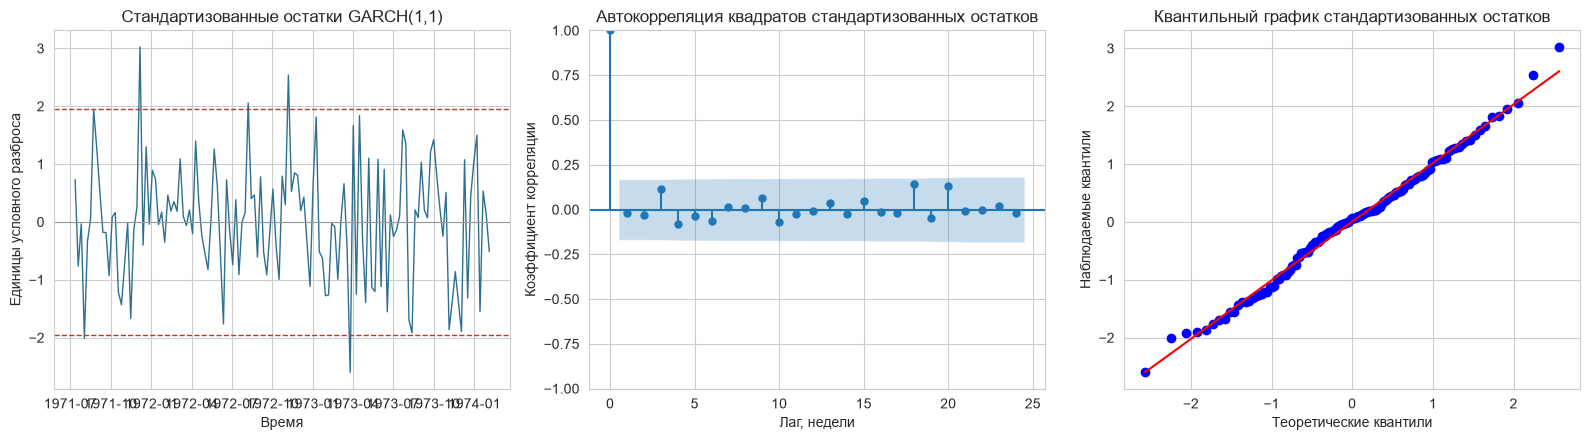

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(станд.index, станд.values, color='#2f6f8f', linewidth=1.0)
axes[0].axhline(0, color='#999999', linewidth=0.8)
axes[0].axhline(1.96, color='#b03a2e', linestyle='--', linewidth=1.0)
axes[0].axhline(-1.96, color='#b03a2e', linestyle='--', linewidth=1.0)
axes[0].set_title('Стандартизованные остатки GARCH(1,1)')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Единицы условного разброса')

plot_acf(станд ** 2, lags=24, ax=axes[1], alpha=0.05)
axes[1].set_title('Автокорреляция квадратов стандартизованных остатков')
axes[1].set_xlabel('Лаг, недели')
axes[1].set_ylabel('Коэффициент корреляции')

stats.probplot(станд.values, dist='norm', plot=axes[2])
axes[2].set_title('Квантильный график стандартизованных остатков')
axes[2].set_xlabel('Теоретические квантили')
axes[2].set_ylabel('Наблюдаемые квантили')

plt.tight_layout()
plt.show()

**Вывод по Задаче 7:**

**ARCH-эффект снят полностью.** До модели тест множителей Лагранжа отвергал постоянство
дисперсии на первом лаге с p-value **0.0255**, после - дает **0.8146**. То же на всех
проверенных глубинах: 4, 8 и 12 лагов дают **0.5647, 0.9281, 0.9471** вместо 0.0695, 0.2462
и 0.3861. Льюнг-Бокс по квадратам стандартизованных остатков вырос с **0.0366** до **0.8748**
на восьми лагах и с 0.0507 до **0.9517** на двенадцати.

**Разброс стандартизованных остатков 1.005** при теоретической единице, то есть масштаб модель
угадала. Асимметрия **0.074**, избыточный куртозис **0.049**, Шапиро-Уилк дает p-value
**0.8423** - нормальное распределение ошибок, заложенное в модель, данным не противоречит.
Квантильный график ложится на прямую по всей длине, включая хвосты.

Значит, с описательной стороны модель к ряду подошла: то, ради чего она строилась, из данных
ушло

### Задача 8. Прогноз дисперсии на отложенных 26 неделях

Описательное качество и прогнозное - разные вещи, и второе проверяется только на данных,
которые в подборе не участвовали. Отложенные 26 недель ждали именно этого.

Схема честная: параметры и ARIMA, и GARCH взяты из обучающей части и больше не пересчитываются,
а условный разброс на каждой следующей неделе обновляется по фактическим остаткам предыдущих.
То есть модель узнает, что произошло, но не переучивается.

Сравнивать GARCH надо не с пустотой, а с правилами, которые она обязана обойти. Их четыре:
постоянная дисперсия обучения, скользящее окно в 13 недель, экспоненциальное сглаживание
квадратов с коэффициентом 0.94 (стандарт RiskMetrics) и чистая ARCH(1) - та же модель
без памяти о собственной дисперсии.

Настоящей дисперсии недели никто не наблюдает, поэтому в качестве меры факта берется квадрат
остатка. Он несмещенная, но крайне шумная оценка, поэтому метрик две: обычная средняя
квадратичная ошибка и QLIKE - специальная функция потерь для дисперсии, которая штрафует
занижение сильнее завышения и не разваливается от единичного выброса

In [24]:
# остатки на всей длине ряда считаются параметрами, оцененными по обучению:
# apply подставляет новые данные в уже обученную модель и ничего не переоценивает
полная_средняя = средняя.apply(доходность)
остатки_все = pd.Series(полная_средняя.resid, index=доходность.index)
print('сверка: максимум расхождения остатков обучения %.10f'
      % np.abs(остатки_все[:-ГОРИЗОНТ].values - остатки.values).max())

граница = остатки_все.index[-ГОРИЗОНТ]
факт_дисп = (остатки_все[-ГОРИЗОНТ:] ** 2).values


def прогноз_дисперсии(vol, p_, q_):
    """обучение на первых 135 неделях, прогноз на шаг вперед для каждой из отложенных 26"""
    м = arch_model(остатки_все, mean='Zero', vol=vol, p=p_, q=q_).fit(disp='off', last_obs=граница)
    return м.forecast(horizon=1, start=граница, reindex=False).variance['h.1'].values, м


пр_garch11, мод11 = прогноз_дисперсии('GARCH', 1, 1)
пр_garch12, мод12 = прогноз_дисперсии('GARCH', 1, 2)
пр_garch22, мод22 = прогноз_дисперсии('GARCH', 2, 2)
пр_arch1, мод_arch = прогноз_дисперсии('ARCH', 1, 0)

# постоянная дисперсия обучения
пр_конст = np.repeat(остатки.var(ddof=1), ГОРИЗОНТ)

# скользящее окно 13 недель: дисперсия последних 13 известных остатков
пр_окно = np.array([остатки_все.iloc[i - 13:i].var(ddof=1) for i in range(len(остатки_все) - ГОРИЗОНТ, len(остатки_все))])

# экспоненциальное сглаживание квадратов остатков, лямбда 0.94
лямбда, s = 0.94, остатки.var(ddof=1)
пр_ewma = []
for t in range(len(остатки_все)):
    if t >= len(остатки_все) - ГОРИЗОНТ:
        пр_ewma.append(s)
    s = лямбда * s + (1 - лямбда) * остатки_все.iloc[t] ** 2
пр_ewma = np.array(пр_ewma)

print('квадраты остатков на проверке: среднее %.2f, медиана %.2f, максимум %.2f'
      % (факт_дисп.mean(), np.median(факт_дисп), факт_дисп.max()))

сверка: максимум расхождения остатков обучения 0.0000000000
квадраты остатков на проверке: среднее 6.90, медиана 2.92, максимум 44.89


In [25]:
def qlike(прогноз, факт):
    """функция потерь для дисперсии: штрафует занижение сильнее завышения"""
    о = факт / прогноз
    return о - np.log(о) - 1


модели = [('GARCH(1,1)', пр_garch11), ('GARCH(1,2), минимум AIC', пр_garch12),
          ('GARCH(2,2), порядки от ARIMA', пр_garch22),
          ('ARCH(1)', пр_arch1), ('EWMA, лямбда 0.94', пр_ewma),
          ('скользящее окно 13 недель', пр_окно), ('постоянная дисперсия обучения', пр_конст)]

итог = pd.DataFrame([{
    'модель': имя,
    'MSE': round(np.mean((факт_дисп - пр) ** 2), 2),
    'QLIKE': round(qlike(пр, факт_дисп).mean(), 4),
    'средний прогноз разброса': round(np.sqrt(пр).mean(), 3),
    'размах прогноза разброса': round(np.sqrt(пр).max() - np.sqrt(пр).min(), 3),
    'покрытие полосы 95%': round(float(np.mean(np.abs(остатки_все[-ГОРИЗОНТ:].values) <= 1.96 * np.sqrt(пр))), 3),
} for имя, пр in модели]).set_index('модель')
print('фактический разброс остатков на проверке %.3f' % остатки_все[-ГОРИЗОНТ:].std(ddof=1))
for имя, пр in [('GARCH(1,1)', пр_garch11), ('ARCH(1)', пр_arch1)]:
    print('%-11s прогноз разброса от %.3f%% до %.3f%%' % (имя, np.sqrt(пр).min(), np.sqrt(пр).max()))
итог

фактический разброс остатков на проверке 2.642
GARCH(1,1)  прогноз разброса от 2.426% до 2.857%
ARCH(1)     прогноз разброса от 1.817% до 3.632%


,MSE,QLIKE,средний прогноз разброса,размах прогноза разброса,покрытие полосы 95%
модель,,,,,
"GARCH(1,1)",95.44,1.7133,2.628,0.431,0.962
"GARCH(1,2), минимум AIC",81.38,1.5869,2.638,1.309,0.962
"GARCH(2,2), порядки от ARIMA",81.38,1.5871,2.638,1.309,0.962
ARCH(1),66.19,1.3413,2.152,1.815,1.000
"EWMA, лямбда 0.94",107.95,1.8445,2.645,0.441,0.923
скользящее окно 13 недель,111.96,1.8867,2.702,0.906,0.962
постоянная дисперсия обучения,108.75,1.9136,2.064,0.000,0.885


In [26]:
# средние по 26 неделям сравнивать мало: разница может держаться на двух-трех неделях.
# Парный критерий и бутстрэп смотрят на распределение разности, а не на ее среднее
def парно(пр_a, пр_b, имя_a, имя_b):
    a, b = qlike(пр_a, факт_дисп), qlike(пр_b, факт_дисп)
    п = stats.wilcoxon(a, b)[1]
    гсч = np.random.default_rng(7)
    разности = [np.mean(a[i] - b[i]) for i in (гсч.integers(0, ГОРИЗОНТ, ГОРИЗОНТ) for _ in range(5000))]
    низ, верх = np.percentile(разности, [2.5, 97.5])
    return {'сравнение': '%s против %s' % (имя_a, имя_b),
            'средняя разность QLIKE': round(np.mean(a) - np.mean(b), 4),
            'интервал бутстрэпа': '[%.3f, %.3f]' % (низ, верх),
            'недель в пользу первой': int((a < b).sum()),
            'Уилкоксон p-value': round(п, 4)}


пары = pd.DataFrame([
    парно(пр_garch11, пр_конст, 'GARCH(1,1)', 'постоянная'),
    парно(пр_arch1, пр_конст, 'ARCH(1)', 'постоянная'),
    парно(пр_garch11, пр_arch1, 'GARCH(1,1)', 'ARCH(1)'),
    парно(пр_garch11, пр_garch22, 'GARCH(1,1)', 'GARCH(2,2)'),
    парно(пр_garch11, пр_garch12, 'GARCH(1,1)', 'GARCH(1,2)'),
]).set_index('сравнение')
пары

,средняя разность QLIKE,интервал бутстрэпа,недель в пользу первой,Уилкоксон p-value
сравнение,,,,
"GARCH(1,1) против постоянная",-0.2003,"[-0.650, 0.141]",9,1.0000
ARCH(1) против постоянная,-0.5723,"[-1.122, -0.226]",25,0.0000
"GARCH(1,1) против ARCH(1)",0.3720,"[0.219, 0.535]",6,0.0002
"GARCH(1,1) против GARCH(2,2)",0.1262,"[0.027, 0.243]",10,0.0493
"GARCH(1,1) против GARCH(1,2)",0.1263,"[0.027, 0.243]",10,0.0493


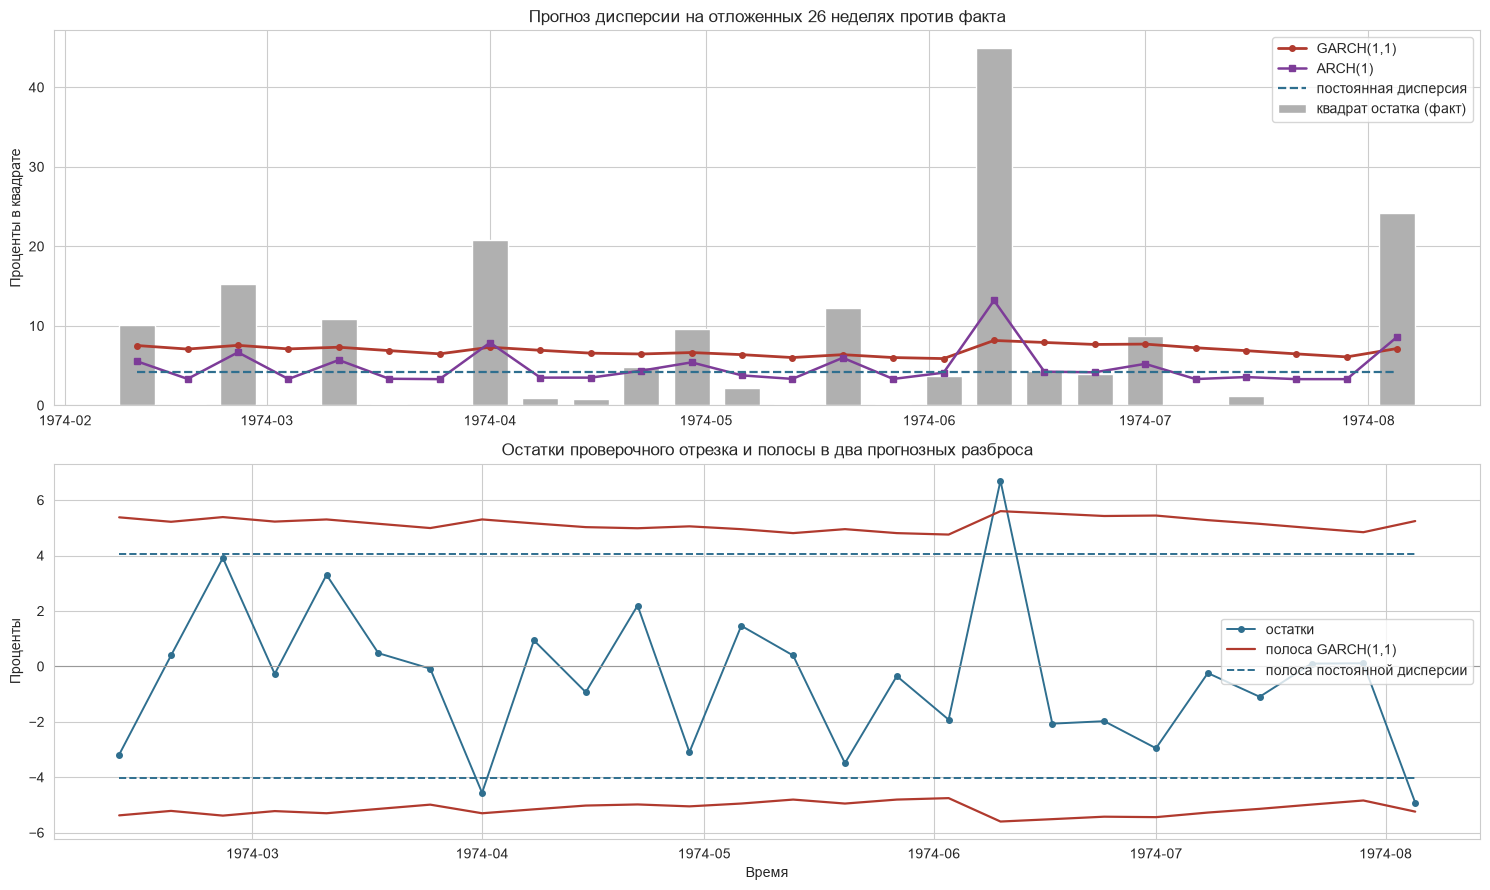

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

даты = остатки_все.index[-ГОРИЗОНТ:]
axes[0].bar(даты, факт_дисп, width=5, color='#b0b0b0', label='квадрат остатка (факт)')
axes[0].plot(даты, пр_garch11, color='#b03a2e', linewidth=2.0, marker='o', markersize=4, label='GARCH(1,1)')
axes[0].plot(даты, пр_arch1, color='#7d3c98', linewidth=1.8, marker='s', markersize=4, label='ARCH(1)')
axes[0].plot(даты, пр_конст, color='#2f6f8f', linewidth=1.6, linestyle='--', label='постоянная дисперсия')
axes[0].set_title('Прогноз дисперсии на отложенных 26 неделях против факта')
axes[0].set_ylabel('Проценты в квадрате')
axes[0].legend()

axes[1].plot(даты, остатки_все[-ГОРИЗОНТ:].values, color='#2f6f8f', linewidth=1.4, marker='o',
             markersize=4, label='остатки')
axes[1].plot(даты, 1.96 * np.sqrt(пр_garch11), color='#b03a2e', linewidth=1.6, label='полоса GARCH(1,1)')
axes[1].plot(даты, -1.96 * np.sqrt(пр_garch11), color='#b03a2e', linewidth=1.6)
axes[1].plot(даты, 1.96 * np.sqrt(пр_конст), color='#2f6f8f', linewidth=1.4, linestyle='--',
             label='полоса постоянной дисперсии')
axes[1].plot(даты, -1.96 * np.sqrt(пр_конст), color='#2f6f8f', linewidth=1.4, linestyle='--')
axes[1].axhline(0, color='#999999', linewidth=0.8)
axes[1].set_title('Остатки проверочного отрезка и полосы в два прогнозных разброса')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Проценты')
axes[1].legend()

plt.tight_layout()
plt.show()

**Вывод по Задаче 8:**

**Все условные модели обходят постоянную дисперсию, и это главный положительный результат.**
По QLIKE: ARCH(1) **1.3413**, GARCH(1,2) **1.5869**, GARCH(2,2) **1.5871**, GARCH(1,1)
**1.7133**, EWMA **1.8445**, скользящее окно **1.8867** против **1.9136** у постоянной.
По средней квадратичной ошибке порядок почти тот же. То есть учитывать изменчивость дисперсии
на этом ряде выгодно. Заодно видно, что GARCH(1,2) и GARCH(2,2) дают одно и то же с точностью
до четвертого знака: сведя два своих коэффициента в ноль, вторая просто стала первой.

**Но выигрыш GARCH(1,1) над постоянной дисперсией статистически не подтверждается.** Средняя
разность QLIKE **-0.2003** в пользу модели, а парный критерий Уилкоксона по тем же 26 неделям
дает **p-value 1.0000**, и модель лучше лишь в **9 неделях из 26**. Бутстрэп разности
по неделям дает интервал **[-0.650, 0.141]**, который ноль накрывает. Смысл расхождения виден
на графике: GARCH выигрывает крупно на нескольких бурных неделях и понемногу проигрывает
на большинстве спокойных, а среднее вытягивают именно первые.

**У ARCH(1) выигрыш над постоянной дисперсией как раз подтверждается**: **25 недель из 26**
в ее пользу, p-value **0.0000**, интервал бутстрэпа **[-1.122, -0.226]** ноль не накрывает.
И она же обходит GARCH(1,1) - **20 недель из 26**, p-value **0.0002**. Разница между
GARCH(1,1) и GARCH(1,2) тоже в пользу второй, но куда слабее: 16 недель из 26, p-value
**0.0493**, интервал **[0.027, 0.243]** едва отходит от нуля.

**Причина видна в размахе прогноза, а не в устройстве моделей.** Прогноз GARCH(1,1) на всем
проверочном отрезке лежит между **2.426% и 2.857%** разброса - размах **0.431**. У ARCH(1)
он идет от **1.817% до 3.632%**, размах **1.815**, вчетверо шире. При персистентности 0.987
условная дисперсия GARCH почти не двигается за полгода вперед и работает как повышенный
постоянный уровень. Фактические квадраты остатков при этом распределены очень неровно:
среднее **6.90**, а медиана всего **2.92** при максимуме **44.89**. GARCH угадывает среднее
(ее средний прогноз разброса **2.628%** против фактических **2.642%**) и промахивается мимо
типичной недели, а ARCH(1) с ее короткой памятью успевает и опускаться на спокойных неделях,
и подниматься на бурных.

**По покрытию интервала выигрыш условных моделей нагляднее всего.** Полоса в два прогнозных
разброса у GARCH накрывает **96.2%** остатков при ожидаемых 95%, у ARCH(1) - **100%**,
а у постоянной дисперсии только **88.5%**: она систематически недооценивает риск бурного
полугодия. Разница между первыми двумя объясняется одним числом: самый крупный остаток
проверки по модулю равен корню из 44.89, то есть **6.70%**, и в полосу ARCH(1) он проходит
(ее максимальный прогноз разброса 3.632%, полоса **7.12%**), а в полосу GARCH нет
(максимум 2.857%, полоса **5.60%**)

### Задача 9. Устойчив ли этот результат

Двадцать шесть недель - короткий отрезок, и порядок моделей на нем может оказаться случайным.
Проверяемый вопрос простой: сохранится ли картина, если сдвинуть границу между обучением
и проверкой.

Повторим весь расчет для четырех длин отложенного хвоста - квартал, полгода, три квартала
и год. Каждый раз ARIMA и GARCH переобучаются заново на своей обучающей части, так что
никакой отложенный отрезок в подбор не попадает

In [28]:
def прогон(h):
    """весь путь целиком для заданной длины отложенного хвоста"""
    об_h = доходность[:-h]
    ср_h = ARIMA(об_h, order=(2, 0, 2), trend='c').fit(method_kwargs={'maxiter': 500})
    ост_h = pd.Series(ср_h.apply(доходность).resid, index=доходность.index)
    гр = ост_h.index[-h]
    факт_h = (ост_h[-h:] ** 2).values
    строки = []
    for имя, vol, p_, q_ in [('GARCH(1,1)', 'GARCH', 1, 1), ('ARCH(1)', 'ARCH', 1, 0)]:
        м = arch_model(ост_h, mean='Zero', vol=vol, p=p_, q=q_).fit(disp='off', last_obs=гр)
        пр = м.forecast(horizon=1, start=гр, reindex=False).variance['h.1'].values
        строки.append((имя, пр, м))
    конст_h = np.repeat(ост_h[:-h].var(ddof=1), h)
    ql = {имя: qlike(пр, факт_h).mean() for имя, пр, _ in строки}
    ql['постоянная'] = qlike(конст_h, факт_h).mean()
    g = [пр for имя, пр, _ in строки if имя == 'GARCH(1,1)'][0]
    a = [пр for имя, пр, _ in строки if имя == 'ARCH(1)'][0]
    м_g = [м for имя, пр, м in строки if имя == 'GARCH(1,1)'][0]
    м_a = [м for имя, пр, м in строки if имя == 'ARCH(1)'][0]
    строка = {'хвост, недель': h, 'обучение, недель': len(об_h),
            'персистентность GARCH': round(sum(v for k, v in м_g.params.items() if k != 'omega'), 4),
            'QLIKE GARCH(1,1)': round(ql['GARCH(1,1)'], 4), 'QLIKE ARCH(1)': round(ql['ARCH(1)'], 4),
            'QLIKE постоянной': round(ql['постоянная'], 4),
            'GARCH лучше постоянной': 'да' if ql['GARCH(1,1)'] < ql['постоянная'] else 'нет',
            'альфа ARCH(1)': round(float(м_a.params['alpha[1]']), 4),
            'p-value альфы ARCH(1)': round(float(м_a.pvalues['alpha[1]']), 4),
            'недель за ARCH(1) против GARCH': '%d из %d' % ((qlike(a, факт_h) < qlike(g, факт_h)).sum(), h),
            'Уилкоксон ARCH против GARCH': round(stats.wilcoxon(qlike(a, факт_h), qlike(g, факт_h))[1], 4)}
    return строка, {'разность QLIKE': qlike(a, факт_h) - qlike(g, факт_h), 'прогноз ARCH(1)': a}


прогоны = {h: прогон(h) for h in (13, 26, 39, 52)}
устойчивость = pd.DataFrame([с for с, _ in прогоны.values()]).set_index('хвост, недель')
устойчивость.T

"хвост, недель",13,26,39,52
"обучение, недель",148,135,122,109
персистентность GARCH,0.9767,0.9874,0.998,0.9497
"QLIKE GARCH(1,1)",1.0437,1.7133,0.9485,1.1535
QLIKE ARCH(1),0.7809,1.3413,0.8381,1.6077
QLIKE постоянной,1.2761,1.9136,1.3878,1.5961
GARCH лучше постоянной,да,да,да,да
альфа ARCH(1),0.1861,0.2203,0.1429,0.0
p-value альфы ARCH(1),0.1175,0.0277,0.4243,1.0
недель за ARCH(1) против GARCH,11 из 13,20 из 26,22 из 39,29 из 52
Уилкоксон ARCH против GARCH,0.0017,0.0002,0.2357,0.0993


In [29]:
# на годовом хвосте средняя разность меняет знак - проверяем, не держится ли она
# на одной неудачной неделе. Выбрасываем худшие для ARCH недели по одной
разность = прогоны[52][1]['разность QLIKE']
порядок = np.argsort(-разность)
print('годовой хвост, разность QLIKE (ARCH минус GARCH): среднее %.4f, медиана %.4f,'
      ' недель в пользу ARCH %d из 52'
      % (разность.mean(), np.median(разность), int((разность < 0).sum())))
for k in (1, 2, 3, 5, 8):
    print('  без %d худших для ARCH недель: среднее %.4f'
          % (k, np.delete(разность, порядок[:k]).mean()))

print('\nпрогноз дисперсии ARCH(1): на годовом хвосте от %.2f до %.2f,'
      ' на полугодовом от %.2f до %.2f'
      % (прогоны[52][1]['прогноз ARCH(1)'].min(), прогоны[52][1]['прогноз ARCH(1)'].max(),
         прогоны[26][1]['прогноз ARCH(1)'].min(), прогоны[26][1]['прогноз ARCH(1)'].max()))

годовой хвост, разность QLIKE (ARCH минус GARCH): среднее 0.4542, медиана -0.0496, недель в пользу ARCH 29 из 52
  без 1 худших для ARCH недель: среднее 0.3619
  без 2 худших для ARCH недель: среднее 0.3001
  без 3 худших для ARCH недель: среднее 0.2492
  без 5 худших для ARCH недель: среднее 0.1701
  без 8 худших для ARCH недель: среднее 0.0521

прогноз дисперсии ARCH(1): на годовом хвосте от 3.36 до 3.36, на полугодовом от 3.30 до 13.19


**Вывод по Задаче 9:**

**Одно утверждение держится на всех четырех разбиениях: условная дисперсия лучше постоянной.**
QLIKE у GARCH(1,1) ниже, чем у постоянной дисперсии, при хвосте в 13, 26, 39 и 52 недели -
**1.044 против 1.276**, **1.713 против 1.914**, **0.949 против 1.388**, **1.154 против 1.596**.
Четыре из четырех, и сам разрыв всюду заметный.

**А вот порядок между самими условными моделями не держится.** ARCH(1) уверенно впереди
на квартале (**11 недель из 13**, p-value 0.0017) и на полугодии (**20 из 26**, p-value 0.0002),
на трех кварталах разница исчезает (**22 из 39**, p-value 0.236), а на годе знак средней меняется
на противоположный: у GARCH QLIKE **1.154** против **1.608** у ARCH, хотя по числу недель
ARCH все еще формально впереди (**29 из 52**). На этом же хвосте ARCH(1) оказывается хуже даже
постоянной дисперсии (1.608 против **1.596**) - единственный такой случай из четырех.

**Причина этой смены знака замерена, и она не в одной неудачной неделе.** На годовом
хвосте коэффициент альфа у ARCH(1) садится ровно в **0.0000** с p-value **1.000**: модель
перестает быть условной вообще и выдает один и тот же прогноз **3.36** на все 52 недели.
То есть с постоянной дисперсией там сравнивается другая постоянная дисперсия, и проигрыш
выходит не моделью, а константой. Само среднее при этом на одной неделе не держится:
если выбросить худшую для ARCH неделю, разность QLIKE падает с **0.454** до **0.362**,
если три - до **0.249**, и только после восьми она сходит почти на нет (**0.052**).
Медиана разности при этом **-0.050**, то есть на типичной неделе ARCH все еще впереди.

**Неустойчива и сама альфа.** По четырем разбиениям она идет **0.186, 0.220, 0.143,
0.000** и значима ровно на одном из них - на полугодии (**p-value 0.0277** против 0.1175,
0.4243 и 1.000). Преимущество ARCH(1) над GARCH держится на коэффициенте, который на трех
границах из четырех от нуля не отличим.

**Персистентность GARCH при этом сама скачет** от **0.950** до **0.998** в зависимости
от того, где провести границу. Это признак того, что параметр оценивается по 109-148 точкам
крайне неустойчиво, и опираться на конкретное его значение нельзя.

Вывод осторожный и ровно по замерам: на этом ряде можно утверждать, что дисперсию стоит
моделировать как переменную, но нельзя утверждать, что именно GARCH(1,1) - лучший способ
это сделать

### Задача 10. Насколько GARCH подходит этому ряду

Задание требует оценить пригодность модели для выбранного ряда, поэтому здесь собраны вместе
все замеры, из которых такая оценка складывается. Каждая строка таблицы - отдельный признак
пригодности и число, которым он проверен

In [30]:
пригодность = pd.DataFrame([
    {'признак': 'ряд приведен к стационарному виду',
     'замер': 'ADF p-value 0.0000, KPSS p-value >0.1', 'ответ': 'да'},
    {'признак': 'дисперсия непостоянна',
     'замер': 'Левене по половинам p-value 0.000001', 'ответ': 'да'},
    {'признак': 'ARCH-эффект есть в остатках модели среднего',
     'замер': 'тест множителей Лагранжа p-value 0.0255', 'ответ': 'да'},
    {'признак': 'модель сходится и коэффициенты значимы',
     'замер': 'альфа p-value 0.014, бета p-value 0.000', 'ответ': 'да'},
    {'признак': 'ARCH-эффект после модели снят',
     'замер': 'тест на 1 лаге 0.0255 стало 0.8146', 'ответ': 'да'},
    {'признак': 'распределение ошибок угадано',
     'замер': 'Шапиро-Уилк по стандартизованным 0.8423', 'ответ': 'да'},
    {'признак': 'прогноз дисперсии лучше постоянной',
     'замер': 'QLIKE 1.713 против 1.914, и так на 4 разбиениях', 'ответ': 'да'},
    {'признак': 'выигрыш над постоянной устойчив по неделям',
     'замер': 'Уилкоксон p-value 1.0000, 9 недель из 26', 'ответ': 'нет'},
    {'признак': 'GARCH лучше более простой ARCH(1)',
     'замер': 'проигрыш на 2 хвостах из 4, p-value 0.0002', 'ответ': 'нет'},
    {'признак': 'порядки ARIMA годятся как порядки GARCH',
     'замер': 'GARCH(2,2) хуже по AIC и BIC, 2 коэффициента в нуле', 'ответ': 'нет'},
]).set_index('признак')
пригодность

,замер,ответ
признак,,
ряд приведен к стационарному виду,"ADF p-value 0.0000, KPSS p-value >0.1",да
дисперсия непостоянна,Левене по половинам p-value 0.000001,да
ARCH-эффект есть в остатках модели среднего,тест множителей Лагранжа p-value 0.0255,да
модель сходится и коэффициенты значимы,"альфа p-value 0.014, бета p-value 0.000",да
ARCH-эффект после модели снят,тест на 1 лаге 0.0255 стало 0.8146,да
распределение ошибок угадано,Шапиро-Уилк по стандартизованным 0.8423,да
прогноз дисперсии лучше постоянной,"QLIKE 1.713 против 1.914, и так на 4 разбиениях",да
выигрыш над постоянной устойчив по неделям,"Уилкоксон p-value 1.0000, 9 недель из 26",нет
GARCH лучше более простой ARCH(1),"проигрыш на 2 хвостах из 4, p-value 0.0002",нет


**Вывод по Задаче 10:**

*   **Ряд для GARCH подходящий, и все предварительные условия выполнены.** Логарифмическая
    доходность стационарна по обоим тестам, дисперсия достоверно непостоянна (Левене
    **p-value 0.000001**), ARCH-эффект в остатках модели среднего значим (**0.0255**).
    Это не тот случай, когда модель применяют к ряду, которому она не нужна.
*   **Как описание ряда GARCH(1,1) работает хорошо.** Она снимает ARCH-эффект полностью
    (**0.0255** превращается в **0.8146**, и то же на всех проверенных глубинах), ее
    стандартизованные остатки имеют разброс **1.005** и не отличаются от нормальных
    (**p-value 0.8423**), а полоса в два условных разброса накрывает **96.3%** наблюдений
    при ожидаемых 95%. Условный разброс идет от **1.565%** до **2.934%** и повторяет скользящий
    разброс с корреляцией **0.924**.
*   **Как прогноз GARCH полезна, но выигрыш небольшой и внутри шума.** Она обходит постоянную
    дисперсию на всех четырех проверенных разбиениях, и покрытие интервала у нее заметно лучше
    (**96.2%** против 88.5%). Но на отложенном полугодии парный критерий разницы не видит
    (**p-value 1.0000**, 9 недель из 26), а бутстрэп дает интервал **[-0.650, 0.141]**,
    накрывающий ноль.
*   **Главное ограничение - в том, какого рода изменчивость у этого ряда.** Персистентность
    **0.987** означает полураспад всплеска за **54.5 недели**: модель описывает не быструю
    кластеризацию волатильности, а медленный сдвиг уровня между спокойным 1972 годом (средний
    условный разброс **1.755%**) и бурным 1973-м (**2.237%**). За полгода вперед ее прогноз
    меняется всего на **0.431** процентного пункта разброса, тогда как фактические квадраты
    остатков имеют среднее **6.90** при медиане **2.92** и максимуме **44.89**.
*   **Отсюда и проигрыш простой ARCH(1) на коротких хвостах.** У той размах прогноза **1.815**
    против 0.431, и она успевает опускаться на спокойных неделях: **20 недель из 26** в ее
    пользу при p-value **0.0002**. Более сложная модель проиграла более простой не потому,
    что хуже устроена, а потому что ее сильная сторона - долгая память - на этом ряде мешает.
    Обратная сторона видна на годовом хвосте, где ARCH(1) уходит хуже даже постоянной дисперсии
    (**1.608** против 1.596), а GARCH держится.
*   **Порядки ARIMA, перенесенные в модель дисперсии буквально, ничего не дали.** GARCH(2,2)
    хуже GARCH(1,1) и по AIC (**575.37** против 574.78), и по BIC (**589.89** против 583.50),
    а два своих коэффициента из четырех она ставит ровно в **0.0000**. Порядок модели среднего
    и порядок модели дисперсии - разные вопросы, и решать их надо по отдельности.
*   **Короткий ряд - отдельное ограничение всей работы.** На 135 неделях обучения
    персистентность оценивается в диапазоне от **0.950** до **0.998** в зависимости от границы
    разбиения, безусловная дисперсия по формуле дает **6.370** против выборочных **4.260**,
    а информационные критерии на порядок модели дисперсии указывают в разные стороны
    (AIC на GARCH(1,2), BIC на ARCH(1), и вся таблица умещается в шесть пунктов). Утверждать
    по таким данным, какая именно модель дисперсии лучшая, нельзя; утверждать, что дисперсию
    здесь надо моделировать как переменную, - можно, и это подтверждено четырежды

### Дополнительный эксперимент 1 (вне рамок задания). Асимметричные модели

На занятии разбирались модификации GARCH, в которых падение и рост влияют на будущую дисперсию
по-разному: TGARCH (он же GJR-GARCH) добавляет отдельный коэффициент для отрицательных
отклонений, EGARCH моделирует логарифм дисперсии и включает асимметрию иначе.

Для падающего рынка 1973-1974 годов такая асимметрия выглядит уместной, и проверить ее стоит
двумя способами сразу: подгонкой самих моделей и прямым замером - действительно ли после
отрицательного остатка следующая неделя разбросаннее, чем после положительного

In [31]:
асимм = []
for имя, kw in [('GARCH(1,1)', dict(vol='GARCH', p=1, q=1)),
                ('GJR-GARCH(1,1,1)', dict(vol='GARCH', p=1, o=1, q=1)),
                ('EGARCH(1,1)', dict(vol='EGARCH', p=1, q=1)),
                ('EGARCH(1,1,1)', dict(vol='EGARCH', p=1, o=1, q=1))]:
    м = arch_model(остатки_все, mean='Zero', **kw).fit(disp='off', last_obs=граница)
    пр = м.forecast(horizon=1, start=граница, reindex=False).variance['h.1'].values
    асимм.append({'модель': имя, 'AIC': round(м.aic, 2), 'BIC': round(м.bic, 2),
                  'коэффициент асимметрии': round(м.params.get('gamma[1]', np.nan), 4),
                  'его p-value': round(м.pvalues.get('gamma[1]', np.nan), 4),
                  'QLIKE на проверке': round(qlike(пр, факт_дисп).mean(), 4)})
таб_асимм = pd.DataFrame(асимм).set_index('модель')
print(таб_асимм.to_string())

# прямой замер асимметрии: разброс недели в зависимости от знака предыдущего остатка
предыдущий = остатки.shift(1)
после_падения = остатки[предыдущий < 0].dropna()
после_роста = остатки[предыдущий >= 0].dropna()
print('\nразброс остатка после отрицательного остатка %.3f (%d недель)'
      % (после_падения.std(ddof=1), len(после_падения)))
print('разброс остатка после положительного остатка %.3f (%d недель)'
      % (после_роста.std(ddof=1), len(после_роста)))
print('критерий Левене на равенство этих разбросов: p-value %.4f'
      % stats.levene(после_падения, после_роста)[1])

                     AIC     BIC  коэффициент асимметрии  его p-value  QLIKE на проверке
модель                                                                                  
GARCH(1,1)        574.78  583.50                     NaN          NaN             1.7133
GJR-GARCH(1,1,1)  568.14  579.76                  0.1812       0.8746             1.7227
EGARCH(1,1)       573.30  582.02                     NaN          NaN             1.7489
EGARCH(1,1,1)     565.17  576.79                 -0.1924       0.0037             1.7952

разброс остатка после отрицательного остатка 2.011 (64 недель)
разброс остатка после положительного остатка 2.082 (70 недель)
критерий Левене на равенство этих разбросов: p-value 0.9951


**Вывод по дополнительному эксперименту 1:**

**По информационному критерию асимметрия выглядит нужной, а по прямому замеру ее нет.**
EGARCH с коэффициентом асимметрии дает AIC **565.17** против 574.78 у обычной GARCH(1,1) -
почти десять пунктов выигрыша, и сам коэффициент значим (**p-value 0.0037**). GJR-GARCH тоже
улучшает критерий (**568.14**), но ее коэффициент асимметрии незначим (**p-value 0.8746**)
и вдобавок положителен, то есть указывает в сторону, противоположную ожидаемой.

Прямой замер при этом никакой асимметрии не показывает: разброс недели после отрицательного
остатка **2.011%** (64 недели), после положительного **2.082%** (70 недель), критерий Левене
дает **p-value 0.9951**. Разница не просто незначима, она еще и обратного знака.

**На отложенных неделях асимметричные модели проигрывают.** QLIKE у EGARCH с асимметрией
**1.7952**, у GJR **1.7227** против **1.7133** у простой GARCH(1,1) - обе хуже, причем именно
та, у которой в обучении был самый большой выигрыш по критерию.

Выигрыш в десять пунктов AIC на 135 наблюдениях, не подтвержденный ни прямым замером,
ни отложенной выборкой, - это подгонка под обучающую часть. Асимметричные модели этому ряду
не нужны, и здесь как раз тот случай, когда информационный критерий один, без проверки, решать
не должен

### Дополнительный эксперимент 2 (вне рамок задания). Тот же аппарат на ряде без ARCH-эффекта

Отдельно стоит посмотреть, как ведет себя вся эта схема на ряде, которому она не нужна.
Возьмем из той же папки среднюю месячную температуру воздуха - ряд с сильной годовой волной,
но без всяких оснований ждать в нем кластеризации разброса.

Порядок тот же: привести к стационарному виду, проверить остатки на ARCH-эффект, построить
GARCH. Интересен не результат подгонки, а то, чем отличается картина, когда моделировать
нечего

In [32]:
темп = pd.read_csv('mean-monthly-air-temperature-deg.csv')
темп_ряд = темп['Deg'].astype(float)
темп_ряд.index = pd.PeriodIndex(темп['Month'], freq='M').to_timestamp()
темп_ряд = темп_ряд.asfreq('MS')

# сезонная разность снимает годовую волну, обычная - остаток уровня
темп_ст = темп_ряд.diff(12).diff(1).dropna()
print('температура: %d месяцев, после разностей %d точек' % (len(темп_ряд), len(темп_ст)))
print('ADF p-value %.6f' % adfuller(темп_ст, autolag='BIC')[1])

сравнение_рядов = pd.DataFrame([
    {'ряд': 'доходность Доу-Джонса', 'точек': len(обуч),
     'ARCH-эффект, 1 лаг': round(het_arch(обуч, nlags=1)[1], 4),
     'ARCH-эффект, 4 лага': round(het_arch(обуч, nlags=4)[1], 4),
     'ARCH-эффект, 8 лагов': round(het_arch(обуч, nlags=8)[1], 4),
     'Левене по половинам': round(stats.levene(*np.array_split(обуч.values, 2))[1], 6)},
    {'ряд': 'температура после разностей', 'точек': len(темп_ст),
     'ARCH-эффект, 1 лаг': round(het_arch(темп_ст, nlags=1)[1], 4),
     'ARCH-эффект, 4 лага': round(het_arch(темп_ст, nlags=4)[1], 4),
     'ARCH-эффект, 8 лагов': round(het_arch(темп_ст, nlags=8)[1], 4),
     'Левене по половинам': round(stats.levene(*np.array_split(темп_ст.values, 2))[1], 6)},
]).set_index('ряд')
print()
print(сравнение_рядов.to_string())

температура: 240 месяцев, после разностей 227 точек
ADF p-value 0.000000

                             точек  ARCH-эффект, 1 лаг  ARCH-эффект, 4 лага  ARCH-эффект, 8 лагов  Левене по половинам
ряд                                                                                                                   
доходность Доу-Джонса          135              0.0305               0.0276                0.0236             0.000001
температура после разностей    227              0.3392               0.4979                0.0903             0.818378


                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.4830      1.142      0.423      0.672 [ -1.756,  2.721]
alpha[1]       0.0000  7.298e-02      0.000      1.000 [ -0.143,  0.143]
beta[1]        0.9727      0.134      7.232  4.747e-13 [  0.709,  1.236]

условный разброс: от 4.206 до 4.853, отношение 1.15
для сравнения у Доу-Джонса отношение 1.88
коэффициентов с p-value больше 0.05: 2 из 3


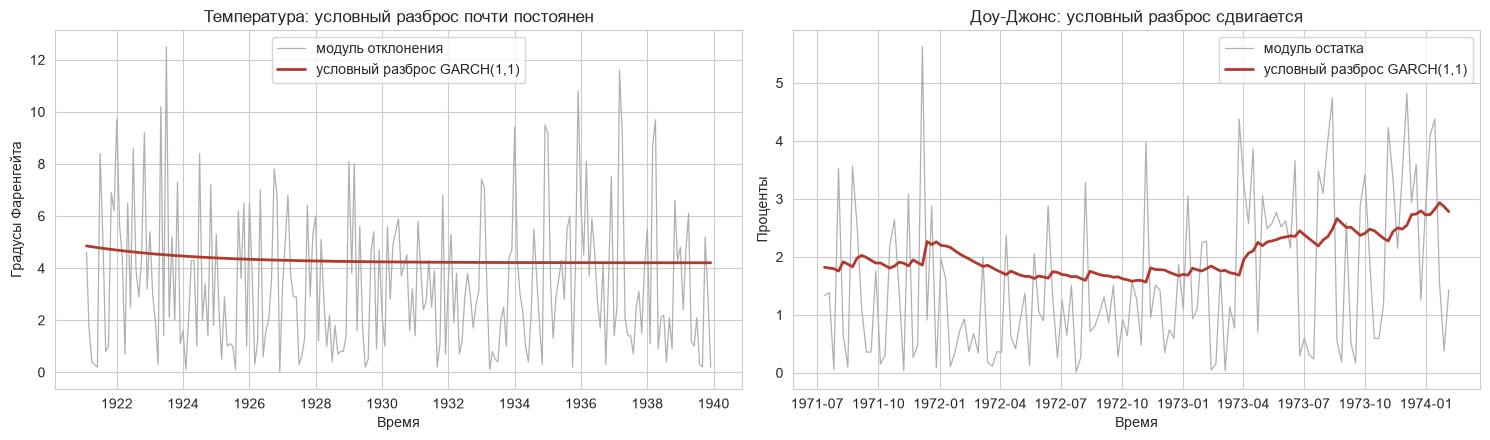

In [33]:
# GARCH все равно посчитается - вопрос в том, что она покажет
темп_garch = arch_model(темп_ст, mean='Zero', vol='GARCH', p=1, q=1).fit(disp='off')
темп_вол = pd.Series(темп_garch.conditional_volatility, index=темп_ст.index)

print(темп_garch.summary().tables[1])
print('\nусловный разброс: от %.3f до %.3f, отношение %.2f'
      % (темп_вол.min(), темп_вол.max(), темп_вол.max() / темп_вол.min()))
print('для сравнения у Доу-Джонса отношение %.2f' % (усл_вол.max() / усл_вол.min()))
print('коэффициентов с p-value больше 0.05: %d из %d'
      % (int((темп_garch.pvalues > 0.05).sum()), len(темп_garch.pvalues)))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(темп_вол.index, темп_ст.abs().values, color='#b0b0b0', linewidth=0.9, label='модуль отклонения')
axes[0].plot(темп_вол.index, темп_вол.values, color='#b03a2e', linewidth=2.0, label='условный разброс GARCH(1,1)')
axes[0].set_title('Температура: условный разброс почти постоянен')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Градусы Фаренгейта')
axes[0].legend()

axes[1].plot(усл_вол.index, остатки.abs().values, color='#b0b0b0', linewidth=0.9, label='модуль остатка')
axes[1].plot(усл_вол.index, усл_вол.values, color='#b03a2e', linewidth=2.0, label='условный разброс GARCH(1,1)')
axes[1].set_title('Доу-Джонс: условный разброс сдвигается')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Проценты')
axes[1].legend()

plt.tight_layout()
plt.show()

**Вывод по дополнительному эксперименту 2:**

**Разница между рядом, которому GARCH нужна, и рядом, которому не нужна, видна по тестам
до всякой подгонки.** У доходности Доу-Джонса ARCH-эффект значим и на первом лаге
(**p-value 0.0305**), и на четвертом (**0.0276**), и на восьмом (**0.0236**). У температуры
после разностей он не значим ни на первом (**0.3392**), ни на четвертом (**0.4979**),
а на восьмом лишь подходит к границе (**0.0903**). Критерий Левене по половинам:
**0.000001** против **0.818378**.

**Модель при этом считается и не жалуется.** Оптимизация сходится, сводка печатается,
и по одной ей отличить осмысленный результат от бессмысленного нельзя. Отличают его две вещи.
Первая: коэффициент при квадратах отклонений встает ровно в **0.0000** с p-value **1.000**,
то есть от прошлых отклонений условная дисперсия не зависит совсем, и от ARCH в модели
не остается ничего. Вторая: условный разброс идет почти прямой линией - отношение максимума
к минимуму **1.15** против **1.88** у Доу-Джонса, и это при вдвое большем числе наблюдений.

Практический смысл этого раздела в том, что проверку на ARCH-эффект надо делать **до** подгонки,
а не после. Готовая модель ничем не выдаст, что моделировать было нечего

### Дополнительный эксперимент 3 (вне рамок задания). Прогноз классическим ML на лагах

Есть подход, который обходится без всей теории временных рядов: сделать из прошлых значений
ряда обычные признаки и отдать их обычной модели регрессии. Он не описывает устройство ряда
и потому неправилен по существу, но считается быстро и часто дает приличный результат.

Проверим его на тех же данных и на том же отложенном отрезке, что и все предыдущие модели,
в двух видах. Сначала по прямому назначению - предсказать сам индекс по десяти его прошлым
значениям. Потом там, где работала GARCH, - предсказать квадрат остатка, то есть меру разброса
недели, по пяти прошлым квадратам.

Обе задачи решаются линейной регрессией и случайным лесом, обе меряются на последних 26 неделях,
и обеим есть с чем сравниться: индексу - с наивным правилом «столько же, сколько на прошлой
неделе» и с ARIMA(2,0,2), разбросу - с GARCH(1,1), ARCH(1) и постоянной дисперсией

In [34]:
# обе задачи этого раздела отличаются только рядом и числом лагов, поэтому механика
# «собрать таблицу лагов и обучить две модели» вынесена в одну функцию
def лаги_и_модели(ряд, k):
    """таблица из k прошлых значений ряда и обученные на ней линейная регрессия и лес"""
    таб = pd.DataFrame({'цель': ряд})
    for i in range(1, k + 1):
        таб['лаг_%d' % i] = ряд.shift(i)
    таб = таб.dropna()
    # граница между обучением и проверкой та же, что во всей работе
    об, тест_ = таб[:-ГОРИЗОНТ], таб[-ГОРИЗОНТ:]
    X_о, y_о = об.drop(columns='цель'), об['цель']
    X_т, y_т = тест_.drop(columns='цель'), тест_['цель']
    лин = LinearRegression().fit(X_о, y_о)
    лес = RandomForestRegressor(n_estimators=300, random_state=10).fit(X_о, y_о)
    return {'X_об': X_о, 'y_об': y_о, 'X_тест': X_т, 'y_тест': y_т, 'лин': лин, 'лес': лес,
            'пр_лин': лин.predict(X_т), 'пр_лес': лес.predict(X_т)}


# первое применение: индекс по десяти своим прошлым значениям
ц = лаги_и_модели(цена, 10)
X_об, y_об, X_тест, y_тест = ц['X_об'], ц['y_об'], ц['X_тест'], ц['y_тест']
лин_цена, лес_цена = ц['лин'], ц['лес']

print('обучение %d недель, проверка %d недель' % (len(y_об), len(y_тест)))
print('индекс в обучении от %.2f до %.2f, в проверке от %.2f до %.2f'
      % (y_об.min(), y_об.max(), y_тест.min(), y_тест.max()))
print('недель проверки ниже минимума обучения: %d из %d' % (int((y_тест < y_об.min()).sum()), ГОРИЗОНТ))

# ARIMA считает доходность, поэтому ее прогноз возвращается в пункты индекса
# умножением прошлой цены на экспоненту предсказанной доходности
пр_доходности = полная_средняя.get_prediction(start=доходность.index[-ГОРИЗОНТ:][0]).predicted_mean.values
пр_arima_цена = цена.shift(1)[-ГОРИЗОНТ:].values * np.exp(пр_доходности / 100)

прогнозы_цены = [
    ('наивный прогноз (прошлая неделя)', X_тест['лаг_1'].values),
    ('ARIMA(2,0,2) через доходность', пр_arima_цена),
    ('линейная регрессия на 10 лагах', лин_цена.predict(X_тест)),
    ('случайный лес на 10 лагах', лес_цена.predict(X_тест)),
]
итог_цены = pd.DataFrame([{
    'модель': имя,
    'RMSE, пунктов': round(float(np.sqrt(np.mean((y_тест.values - п) ** 2))), 3),
    'MAE, пунктов': round(float(np.mean(np.abs(y_тест.values - п))), 3),
    'минимум прогноза': round(float(np.min(п)), 2),
    'максимум прогноза': round(float(np.max(п)), 2),
} for имя, п in прогнозы_цены]).set_index('модель')
print('\nфакт на проверке: от %.2f до %.2f' % (y_тест.min(), y_тест.max()))
итог_цены

обучение 126 недель, проверка 26 недель
индекс в обучении от 810.67 до 1047.49, в проверке от 752.58 до 887.83
недель проверки ниже минимума обучения: 7 из 26

факт на проверке: от 752.58 до 887.83


,"RMSE, пунктов","MAE, пунктов",минимум прогноза,максимум прогноза
модель,,,,
наивный прогноз (прошлая неделя),20.394,15.482,784.57,887.83
"ARIMA(2,0,2) через доходность",21.794,16.358,783.69,886.21
линейная регрессия на 10 лагах,22.665,17.912,789.90,890.05
случайный лес на 10 лагах,38.389,30.505,843.29,896.80


In [35]:
# на что опирается каждая модель: у линейной - веса, у леса - важности признаков
опоры = pd.DataFrame({'вес линейной регрессии': np.round(лин_цена.coef_, 3),
                      'важность в лесу': np.round(лес_цена.feature_importances_, 3)},
                     index=X_об.columns)
print(опоры.to_string())
print('свободный член линейной регрессии %.3f' % лин_цена.intercept_)

        вес линейной регрессии  важность в лесу
лаг_1                    0.943            0.793
лаг_2                    0.035            0.114
лаг_3                    0.115            0.016
лаг_4                   -0.259            0.013
лаг_5                    0.237            0.008
лаг_6                   -0.238            0.014
лаг_7                    0.066            0.009
лаг_8                    0.001            0.013
лаг_9                   -0.061            0.012
лаг_10                   0.115            0.010
свободный член линейной регрессии 42.662


In [36]:
# второе применение той же функции: на месте GARCH, цель - квадрат остатка ARIMA,
# признаки - пять его лагов
д = лаги_и_модели(остатки_все ** 2, 5)
Xк_об, лес_дисп = д['X_об'], д['лес']
пр_лин, пр_лес = д['пр_лин'], д['пр_лес']

# линейная регрессия ничем не удержана от отрицательной дисперсии, а QLIKE от нее
# развалится - поэтому проверяем прямо, а не надеемся
print('отрицательных или нулевых предсказаний дисперсии: у линейной регрессии %d, у леса %d'
      % (int((пр_лин <= 0).sum()), int((пр_лес <= 0).sum())))
print('минимальные предсказания: линейная %.3f, лес %.3f' % (пр_лин.min(), пр_лес.min()))

прогнозы_дисперсии = [('GARCH(1,1)', пр_garch11), ('ARCH(1)', пр_arch1),
                      ('постоянная дисперсия обучения', пр_конст),
                      ('линейная регрессия на 5 лагах квадратов', пр_лин),
                      ('случайный лес на 5 лагах квадратов', пр_лес)]
итог_дисперсии = pd.DataFrame([{
    'модель': имя,
    'MSE': round(float(np.mean((факт_дисп - п) ** 2)), 2),
    'QLIKE': round(float(qlike(п, факт_дисп).mean()), 4),
    'минимум прогноза': round(float(np.min(п)), 2),
    'максимум прогноза': round(float(np.max(п)), 2),
} for имя, п in прогнозы_дисперсии]).set_index('модель')
print()
print(итог_дисперсии.to_string())

for имя, п in [('линейной регрессией', пр_лин), ('случайным лесом', пр_лес)]:
    a, b = qlike(пр_garch11, факт_дисп), qlike(п, факт_дисп)
    print('\nGARCH(1,1) против %s: недель в пользу GARCH %d из %d, Уилкоксон p-value %.4f'
          % (имя, int((a < b).sum()), ГОРИЗОНТ, stats.wilcoxon(a, b)[1]))
print('\nважности лагов в лесу по дисперсии:',
      {к: round(в, 3) for к, в in zip(Xк_об.columns, лес_дисп.feature_importances_)})

отрицательных или нулевых предсказаний дисперсии: у линейной регрессии 0, у леса 0
минимальные предсказания: линейная 2.515, лес 1.405

                                            MSE   QLIKE  минимум прогноза  максимум прогноза
модель                                                                                      
GARCH(1,1)                                95.44  1.7133              5.89               8.16
ARCH(1)                                   66.19  1.3413              3.30              13.19
постоянная дисперсия обучения            108.75  1.9136              4.26               4.26
линейная регрессия на 5 лагах квадратов  114.04  2.0161              2.51              10.77
случайный лес на 5 лагах квадратов       110.75  2.1198              1.41               9.35

GARCH(1,1) против линейной регрессией: недель в пользу GARCH 10 из 26, Уилкоксон p-value 0.7454

GARCH(1,1) против случайным лесом: недель в пользу GARCH 9 из 26, Уилкоксон p-value 0.7265

важности лагов в лесу п

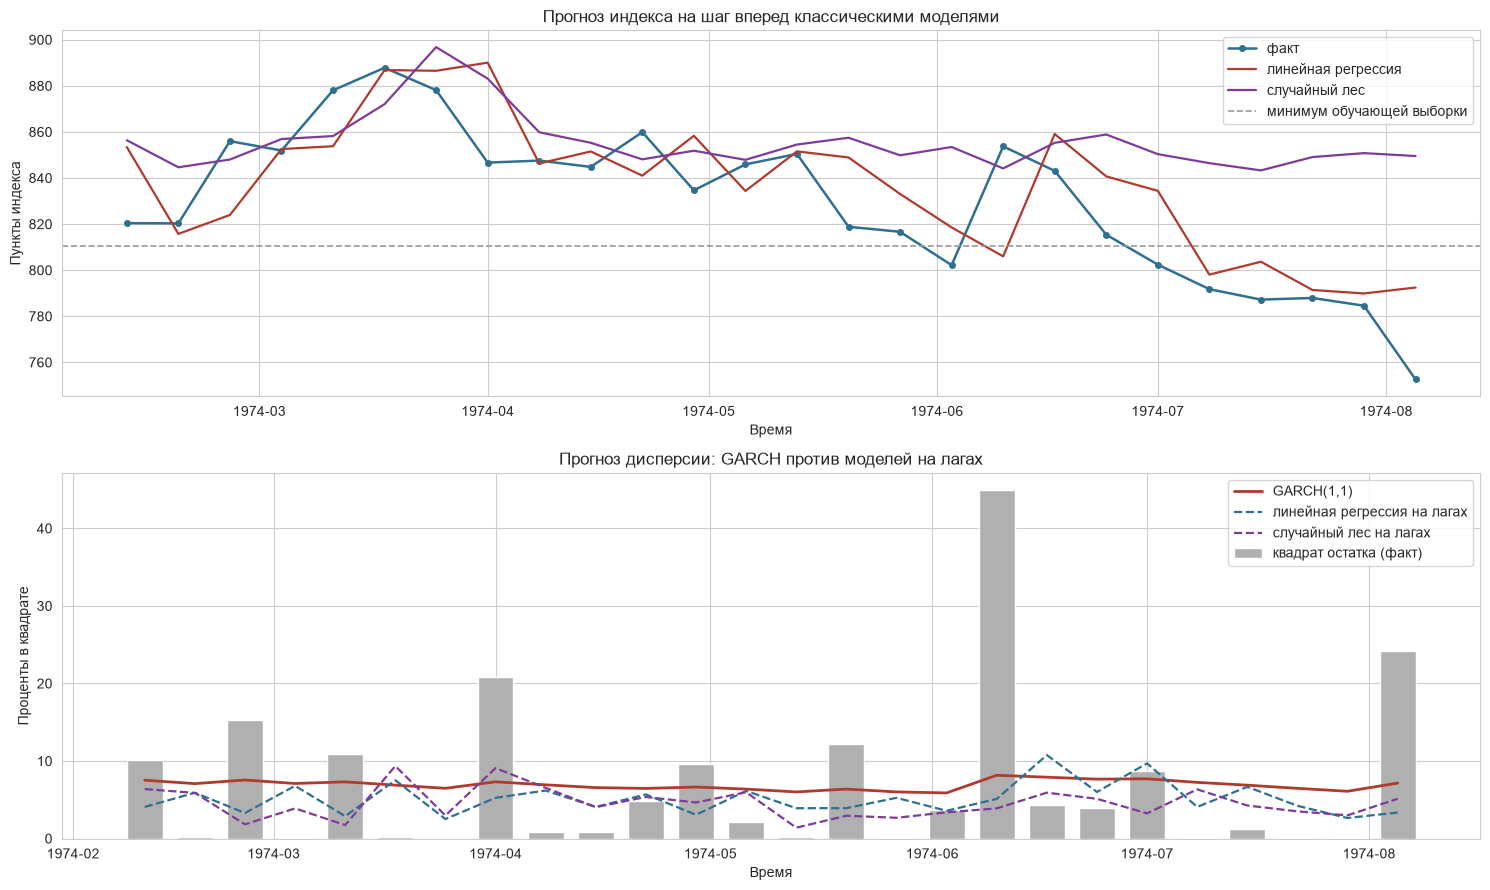

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

axes[0].plot(y_тест.index, y_тест.values, color='#2f6f8f', linewidth=1.8, marker='o', markersize=4, label='факт')
axes[0].plot(y_тест.index, лин_цена.predict(X_тест), color='#b03a2e', linewidth=1.6, label='линейная регрессия')
axes[0].plot(y_тест.index, лес_цена.predict(X_тест), color='#7d3c98', linewidth=1.6, label='случайный лес')
axes[0].axhline(y_об.min(), color='#999999', linestyle='--', linewidth=1.2, label='минимум обучающей выборки')
axes[0].set_title('Прогноз индекса на шаг вперед классическими моделями')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Пункты индекса')
axes[0].legend()

axes[1].bar(даты, факт_дисп, width=5, color='#b0b0b0', label='квадрат остатка (факт)')
axes[1].plot(даты, пр_garch11, color='#b03a2e', linewidth=2.0, label='GARCH(1,1)')
axes[1].plot(даты, пр_лин, color='#2f6f8f', linewidth=1.6, linestyle='--', label='линейная регрессия на лагах')
axes[1].plot(даты, пр_лес, color='#7d3c98', linewidth=1.6, linestyle='--', label='случайный лес на лагах')
axes[1].set_title('Прогноз дисперсии: GARCH против моделей на лагах')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Проценты в квадрате')
axes[1].legend()

plt.tight_layout()
plt.show()

**Вывод по дополнительному эксперименту 3:**

**На самом индексе ни одна модель не обошла наивное правило.** RMSE наивного прогноза
**20.394** пункта, у ARIMA(2,0,2) **21.794**, у линейной регрессии **22.665**, у случайного
леса **38.389**. Это не поражение конкретных моделей, а свойство ряда: приращения индекса
в Задаче 3 оказались почти белым шумом, а лучший прогноз белого шума с накоплением - последнее
известное значение.

**Линейная регрессия к этому правилу и пришла сама.** Вес лага 1 у нее **0.943** при свободном
члене **42.66**, остальные девять весов лежат между -0.259 и 0.237. То есть она построила
слегка притянутый к среднему обучающей выборки наивный прогноз и потеряла на этом притяжении
два пункта RMSE.

**А случайный лес проиграл вдвое, и причина видна прямо в числах.** Его предсказания лежат
между **843.29** и **896.80**, тогда как факт на проверке уходит до **752.58**, а минимум
обучающей выборки - **810.67**. Лес отвечает средним по обучающим значениям, попавшим в лист,
поэтому за пределы обучающего диапазона он не выходит вообще и не дотягивается даже до его
нижнего края. Между тем **7 недель из 26** на проверке лежат ниже всего, что лес видел при
обучении: рынок ушел на новые минимумы, а модель по устройству не может их назвать. Важность
лага 1 у нее **0.793** - опирается она на то же, на что и все, но воспользоваться этим не может.

**На дисперсии те же модели проигрывают даже постоянному числу.** QLIKE у линейной регрессии
**2.0161**, у леса **2.1198** против **1.9136** у постоянной дисперсии обучения и **1.7133**
у GARCH(1,1). По средней квадратичной ошибке линейная тоже хуже постоянной (**114.04** против
108.75), лес почти вровень (**110.75**). Отрицательной дисперсии, от которой развалился бы
QLIKE, ни одна из них не выдала - проверено, минимумы **2.515** и **1.405**.

**Разброс прогнозов при этом у них шире, чем у GARCH** (2.51-10.77 и 1.41-9.35 против
5.89-8.16), то есть двигаться они не боятся - просто двигаются не туда. Важности лагов в лесу
почти ровные (**0.244, 0.154, 0.232, 0.227, 0.143**): никакой лаг не выделился, структуры
он не нашел.

**Но и здесь разница не подтверждается по неделям.** GARCH лучше линейной регрессии в **10**
неделях из 26 (Уилкоксон **p-value 0.7454**) и лучше леса в **9** из 26 (**0.7265**). Средние
у GARCH заметно ниже, а по отдельным неделям модели не различаются - ровно та же картина, что
в Задаче 8 при сравнении с постоянной дисперсией, и то же ограничение: 26 недель мало